In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib import colors
from numpy.ma import masked_invalid
from time import time
from tqdm import tqdm

from util import decode_npy

In [3]:
# relevant constants
DF = pd.read_csv('../data/main_table.csv')
DF = DF.loc[DF.w_median.notnull()]
DF_S82 = pd.read_csv('../data/main_table_S82.csv')
DF_S82 = DF_S82.loc[DF_S82.w_median.notnull()]

FIGURE_PATH = '../figures'

W_MEDIAN_COLNAME = 'w_median'
W_MEAN_COLNAME = 'w_mean'
SGW_COLNAME = 'w_rrms'
W_STD_COLNAME = 'w_std'

D_MEDIAN_COLNAME = 'D_median'
D_MEAN_COLNAME = 'D_mean'
SGD_COLNAME = 'D_rrms'
D_STD_COLNAME = 'D_std'

d_MEDIAN_COLNAME = 'd_median'
d_MEAN_COLNAME = 'd_mean'
SGd_COLNAME = 'd_rrms'
d_STD_COLNAME = 'd_std'

R_MAG_COLNAME  = 'psfMag_r'
G_MAG_COLNAME  = 'psfMag_g'
U_MAG_COLNAME  = 'psfMag_u'
GAIA_G_COLNAME = 'phot_g_mean_mag'

CN = '#f6af00'
CV = '#800080'
CQ = '#007e53'

MIN_W, MAX_W = 0, 2
MIN_SGW, MAX_SGW = 0, 0.5
S = 4

In [4]:
# plot fontsize settings

SMALL_FONT_SIZE = 22
MEDIUM_FONT_SIZE = 28
LARGE_FONT_SIZE = 28

plt.rc('font', size=SMALL_FONT_SIZE)          # default text sizes
plt.rc('axes', titlesize=LARGE_FONT_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_FONT_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_FONT_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_FONT_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_FONT_SIZE)    # legend fontsize
plt.rc('figure', titlesize=LARGE_FONT_SIZE)   # fontsize of the figure title

In [5]:
RES = 100
bins_std = np.linspace(0, 0.5, RES)
bins_avg = np.linspace(0, 2, RES)

AN = 1 #0.15
AV = 1 #0.3
AQ = 1 #0.5

# whole sky

## full resolution, linear

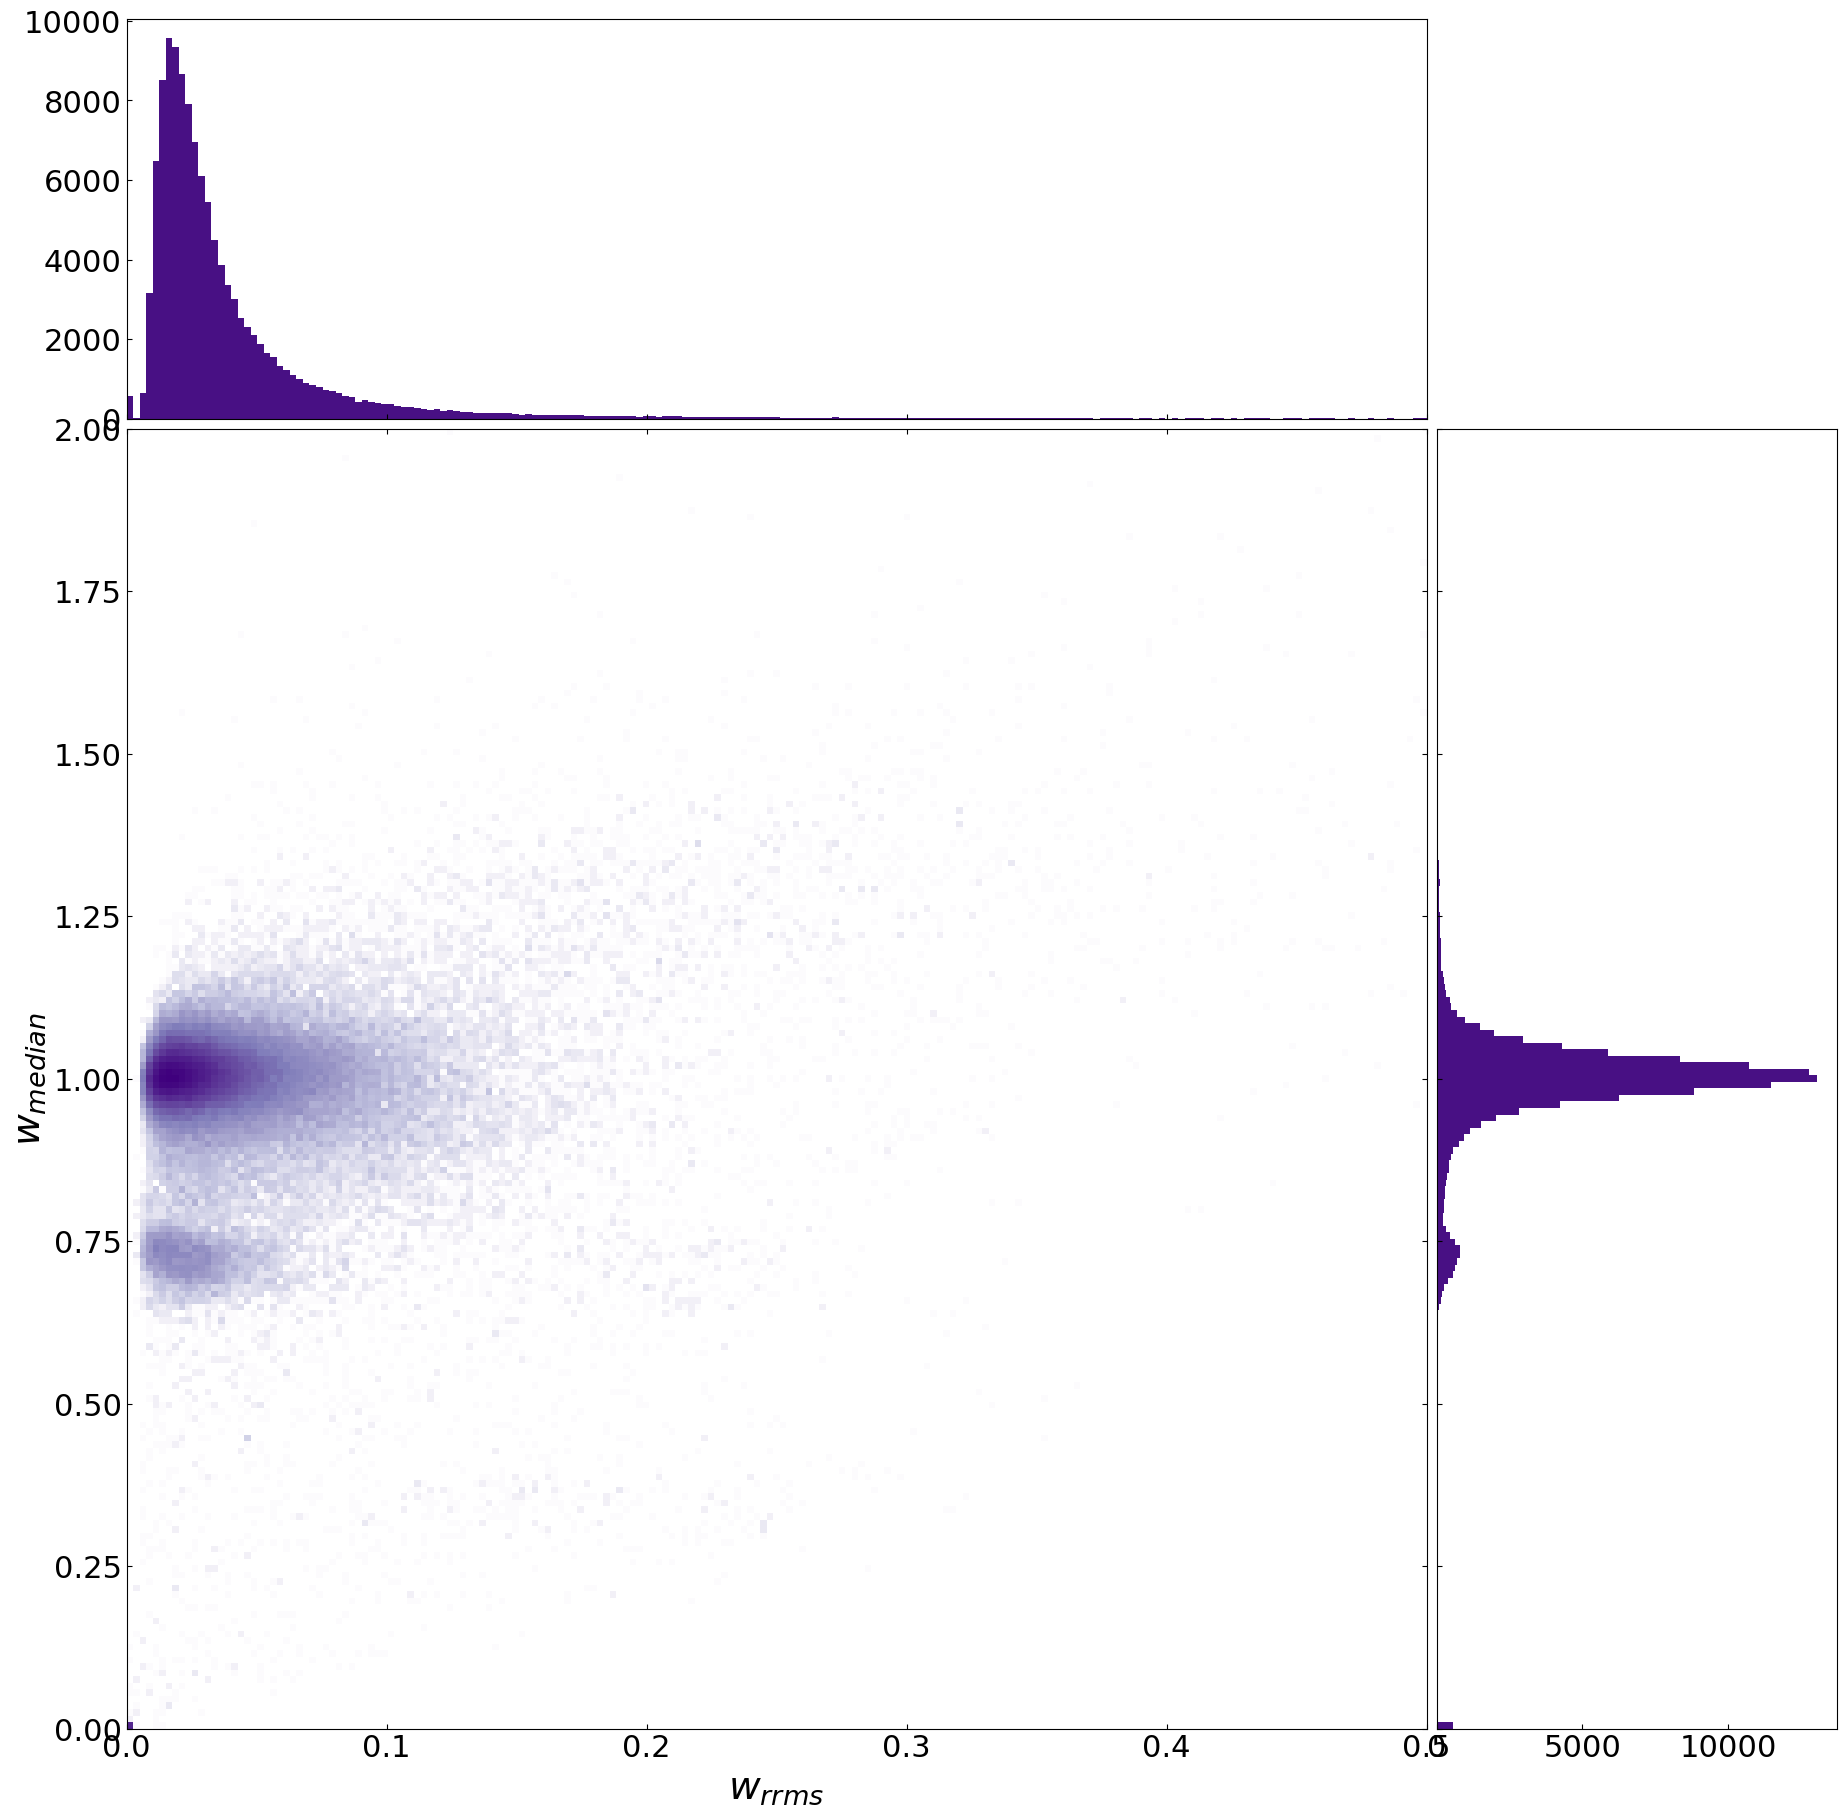

In [6]:
plt.figure(figsize=(20, 20))

# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]


ax_main = plt.axes(rect_scatter)
ax_main.tick_params(direction='in', top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.tick_params(direction='in', labelbottom=False)
ax_histy = plt.axes(rect_histy)
ax_histy.tick_params(direction='in', labelleft=False)


ax_main.set_xlim(MIN_SGW, MAX_SGW)
ax_main.set_ylim(MIN_W, MAX_W)

ax_main.set_xlabel('$w_{rrms}$')
ax_main.set_ylabel('$w_{median}$')

# main 2d histogram
bins_std_4pi = np.linspace(0, 0.5, RES*2)
bins_avg_4pi = np.linspace(0, 2, RES*2)
hist, _, _ = np.histogram2d(DF[SGW_COLNAME], DF[W_MEDIAN_COLNAME],
                            bins=(bins_std_4pi, bins_avg_4pi))

ax_main.pcolormesh(bins_std_4pi, bins_avg_4pi, hist.T, cmap='Purples', norm='log')

# marginal histograms
ax_histx.hist(DF[SGW_COLNAME], bins=bins_std_4pi, color='#481084')
ax_histy.hist(DF[W_MEDIAN_COLNAME], bins=bins_avg_4pi, orientation='horizontal', color='#481084')

ax_histx.set_xlim(ax_main.get_xlim())
ax_histy.set_ylim(ax_main.get_ylim())

# plt.scatter(DF[SGW_COLNAME], DF[W_MEDIAN_COLNAME], c='xkcd:violet',  s=S, alpha=0.2)
# plt.scatter(var_subset[SGW_COLNAME],    var_subset[W_MEDIAN_COLNAME],    c=C_BLUE,    s=S, label='var')
# plt.scatter(quasar_subset[SGW_COLNAME], quasar_subset[W_MEDIAN_COLNAME], c=C_GREEN,   s=S, label='quasar')
# plt.scatter(ambi_subset[SGQ_COLNAME],   ambi_subset[Q_MEDIAN_COLNAME],   c=C_PURPLE,  s=S, label='ambiguous')
# plt.scatter(none_subset[SGQ_COLNAME],   none_subset[Q_MEDIAN_COLNAME],   c=C_BLACK,   s=S, label='unclassified')

# plt.legend()

plt.savefig('../figures/ww_hist_fullres_lin.png', dpi=600)
plt.show()

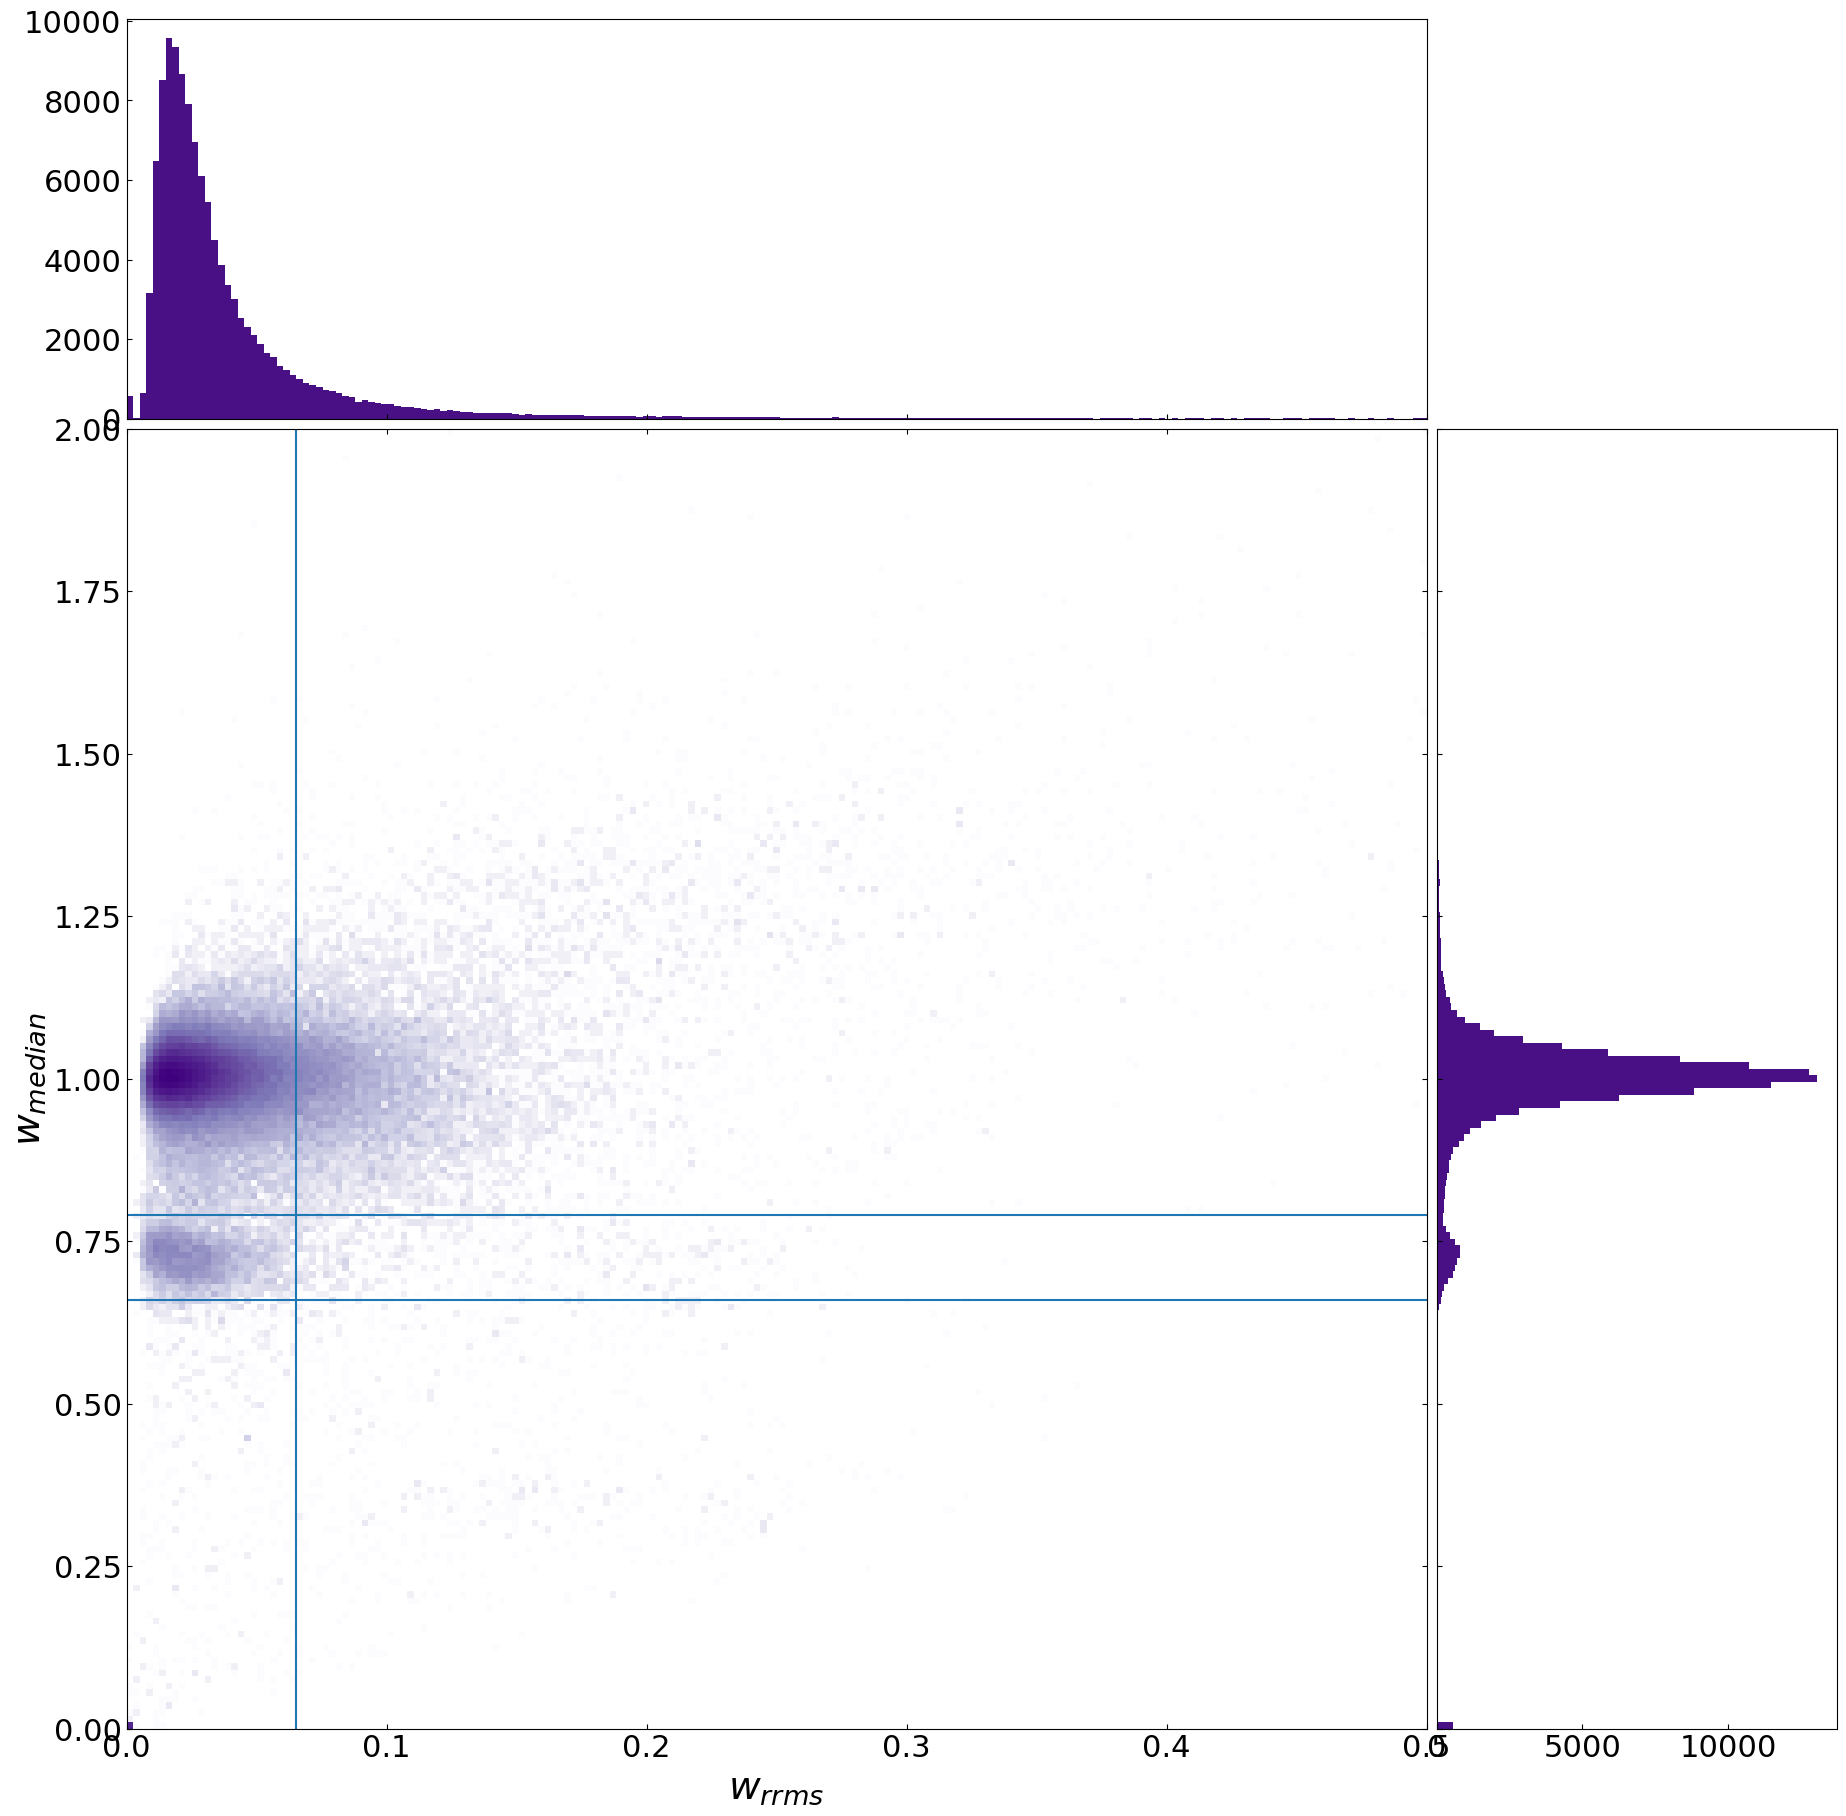

In [7]:
plt.figure(figsize=(20, 20))

# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]


ax_main = plt.axes(rect_scatter)
ax_main.tick_params(direction='in', top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.tick_params(direction='in', labelbottom=False)
ax_histy = plt.axes(rect_histy)
ax_histy.tick_params(direction='in', labelleft=False)


ax_main.set_xlim(MIN_SGW, MAX_SGW)
ax_main.set_ylim(MIN_W, MAX_W)

ax_main.set_xlabel('$w_{rrms}$')
ax_main.set_ylabel('$w_{median}$')

# main 2d histogram
bins_std_4pi = np.linspace(0, 0.5, RES*2)
bins_avg_4pi = np.linspace(0, 2, RES*2)
hist, _, _ = np.histogram2d(DF[SGW_COLNAME], DF[W_MEDIAN_COLNAME],
                            bins=(bins_std_4pi, bins_avg_4pi))

ax_main.pcolormesh(bins_std_4pi, bins_avg_4pi, hist.T, cmap='Purples', norm='log')

# marginal histograms
ax_histx.hist(DF[SGW_COLNAME], bins=bins_std_4pi, color='#481084')
ax_histy.hist(DF[W_MEDIAN_COLNAME], bins=bins_avg_4pi, orientation='horizontal', color='#481084')

ax_histx.set_xlim(ax_main.get_xlim())
ax_histy.set_ylim(ax_main.get_ylim())

# plt.scatter(DF[SGW_COLNAME], DF[W_MEDIAN_COLNAME], c='xkcd:violet',  s=S, alpha=0.2)
# plt.scatter(var_subset[SGW_COLNAME],    var_subset[W_MEDIAN_COLNAME],    c=C_BLUE,    s=S, label='var')
# plt.scatter(quasar_subset[SGW_COLNAME], quasar_subset[W_MEDIAN_COLNAME], c=C_GREEN,   s=S, label='quasar')
# plt.scatter(ambi_subset[SGQ_COLNAME],   ambi_subset[Q_MEDIAN_COLNAME],   c=C_PURPLE,  s=S, label='ambiguous')
# plt.scatter(none_subset[SGQ_COLNAME],   none_subset[Q_MEDIAN_COLNAME],   c=C_BLACK,   s=S, label='unclassified')

# plt.legend()

ax_main.axvline(0.065)
ax_main.axhline(0.79)
ax_main.axhline(0.66)

plt.savefig('../figures/ww_hist_fullres_lin.png', dpi=600)
plt.show()

In [8]:
LIM_MODE_RMS_UPPER = 0.065
LIM_MODE_MED_LOWER = 0.66
LIM_MODE_MED_UPPER = 0.79
LIM_RMS_LOWER = 0.1
LIM_RMS_UPPER = 0.2

In [9]:
gMr = lambda x: x[G_MAG_COLNAME] - x[R_MAG_COLNAME]
uMg = lambda x: x[U_MAG_COLNAME] - x[G_MAG_COLNAME]

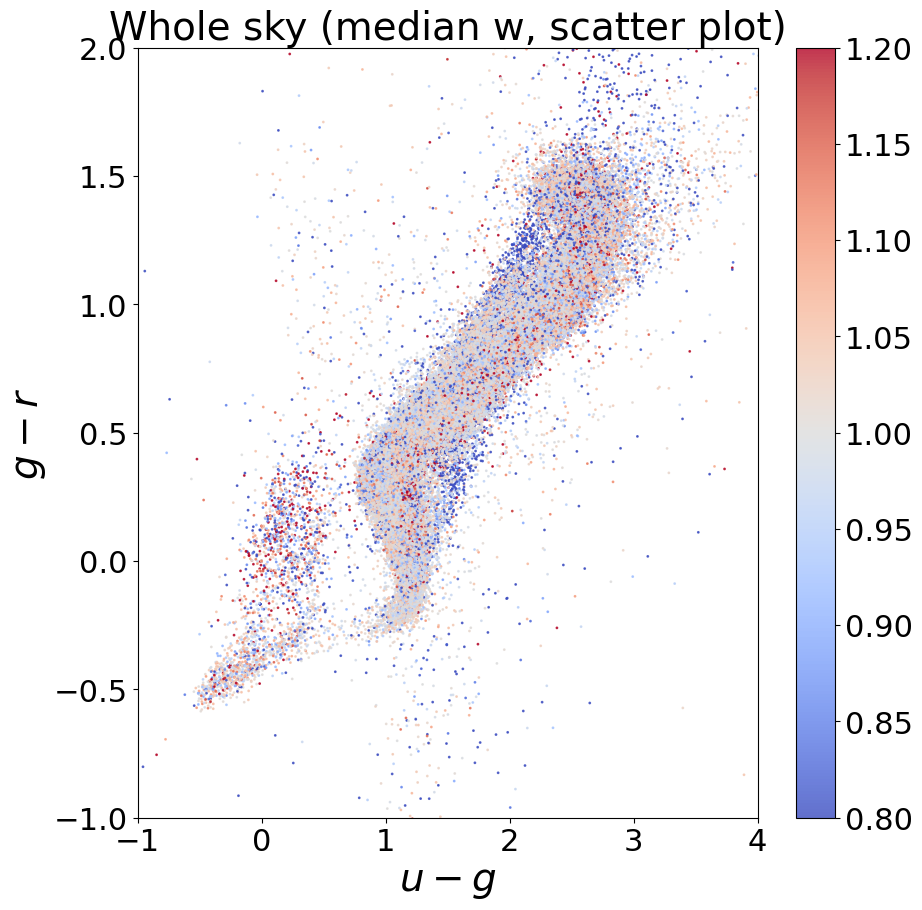

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

S_cc = 1
W_MAX = 1.2
W_MIN = 0.8

ax.set_xlabel('$u-g$')
ax.set_ylabel('$g-r$')
ax.set_xlim(-1, 4)
ax.set_ylim(-1, 2)
ax.set_title('Whole sky (median w, scatter plot)')

sc = ax.scatter(uMg(DF), gMr(DF), s=S_cc, label='all', alpha=0.8,
                cmap='coolwarm', c=DF[W_MEDIAN_COLNAME], vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)

plt.savefig('../figures/cc_whole_sky_scatter.png', dpi=600)

plt.show()

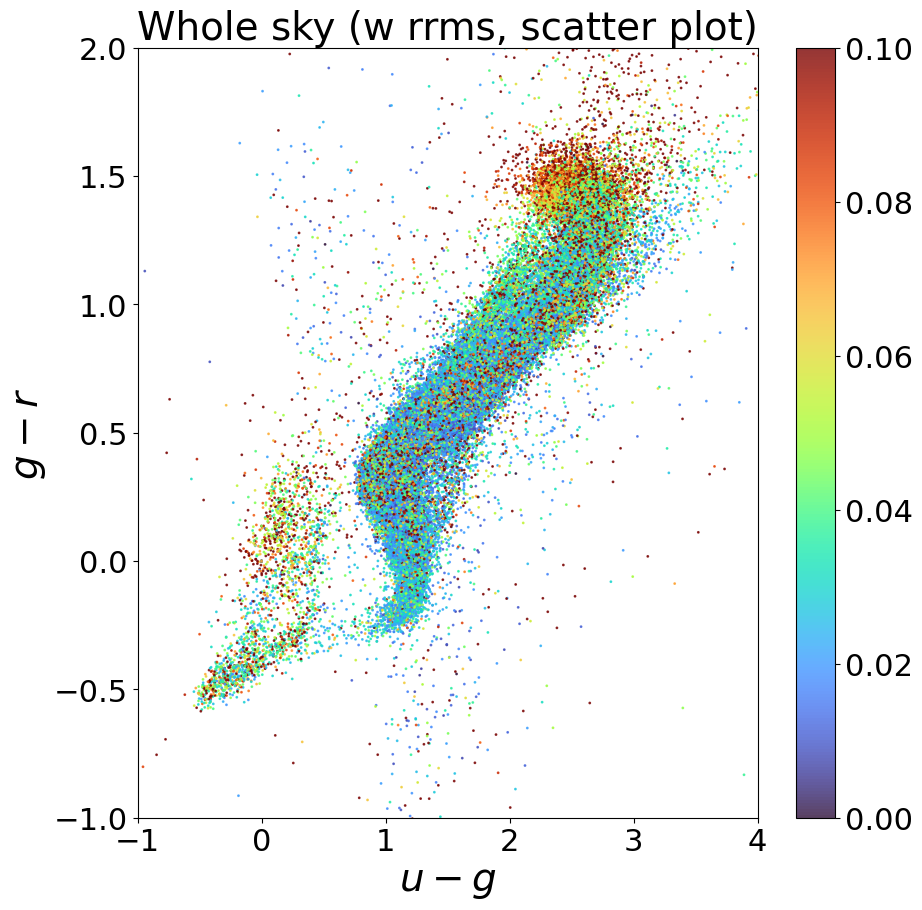

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

S_cc = 1
WR_MAX = 0.1
WR_MIN = 0.0

ax.set_xlabel('$u-g$')
ax.set_ylabel('$g-r$')
ax.set_xlim(-1, 4)
ax.set_ylim(-1, 2)
ax.set_title('Whole sky (w rrms, scatter plot)')

sc = ax.scatter(uMg(DF), gMr(DF), s=S_cc, label='all', alpha=0.8,
                cmap='turbo', c=DF[SGW_COLNAME], vmin=WR_MIN, vmax=WR_MAX)
plt.colorbar(sc)

plt.savefig('../figures/cc_whole_sky_scatter_rrms.png', dpi=600)

plt.show()

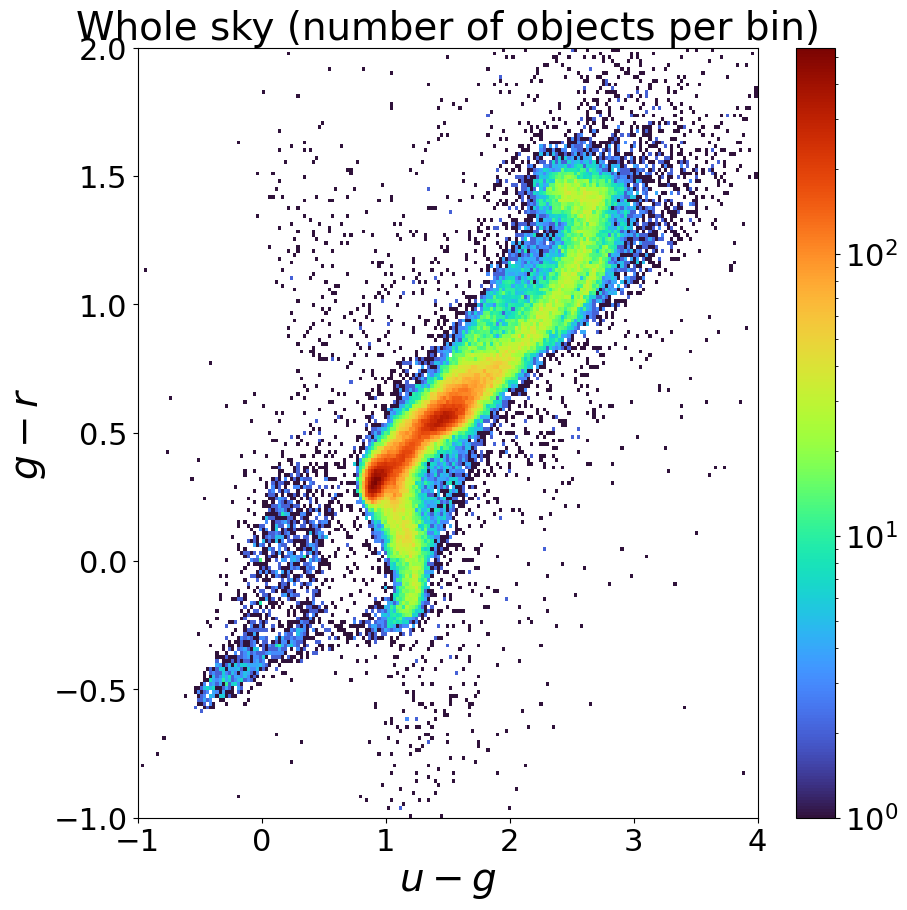

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

S_cc = 1
W_MAX = 1.2
W_MIN = 0.8

ax.set_xlabel('$u-g$')
ax.set_ylabel('$g-r$')
ax.set_xlim(-1, 4)
ax.set_ylim(-1, 2)
ax.set_title('Whole sky (number of objects per bin)')


bins_gMr = np.linspace(-1, 2, RES*2)
bins_uMg = np.linspace(-1, 4, RES*2)
hist, _, _ = np.histogram2d(uMg(DF), gMr(DF), bins=(bins_uMg, bins_gMr))

sc = ax.pcolormesh(bins_uMg, bins_gMr, hist.T, cmap='turbo', norm='log')

# sc = ax.scatter(uMg(DF), gMr(DF), s=S_cc, label='all', alpha=0.8,
#                 cmap='BrBG', c=DF[W_MEDIAN_COLNAME], vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)

plt.savefig('../figures/cc_whole_sky_histogram_number.png', dpi=600)

plt.show()

/tmp/ipykernel_505742/3104790177.py:16: RuntimeWarning: invalid value encountered in divide
  hist_median = np.histogram2d(uMg(DF), gMr(DF), bins=(bins_uMg, bins_gMr), weights=DF[W_MEDIAN_COLNAME])[0]/hist


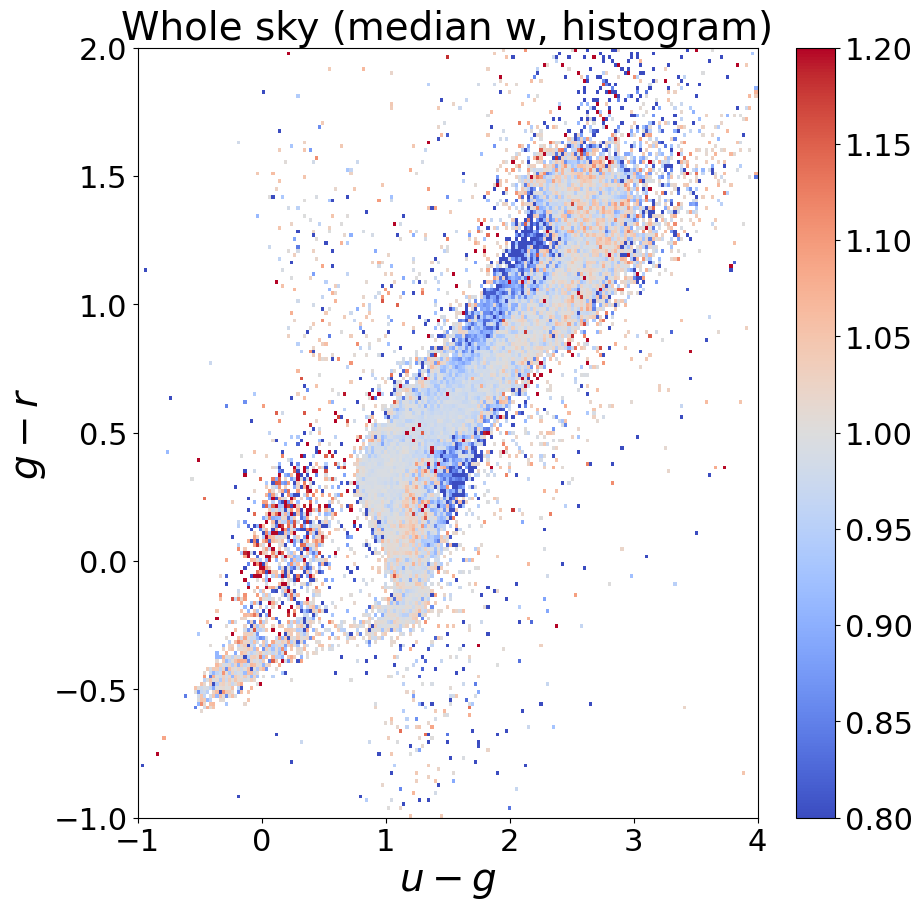

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

S_cc = 1
W_MAX = 1.2
W_MIN = 0.8

ax.set_xlabel('$u-g$')
ax.set_ylabel('$g-r$')
ax.set_xlim(-1, 4)
ax.set_ylim(-1, 2)
ax.set_title('Whole sky (median w, histogram)')


bins_gMr = np.linspace(-1, 2, RES*2)
bins_uMg = np.linspace(-1, 4, RES*2)
hist_median = np.histogram2d(uMg(DF), gMr(DF), bins=(bins_uMg, bins_gMr), weights=DF[W_MEDIAN_COLNAME])[0]/hist

sc = ax.pcolormesh(bins_uMg, bins_gMr, hist_median.T, cmap='coolwarm', norm='linear', vmin=W_MIN, vmax=W_MAX)

# sc = ax.scatter(uMg(DF), gMr(DF), s=S_cc, label='all', alpha=0.8,
#                 cmap='BrBG', c=DF[W_MEDIAN_COLNAME], vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)

plt.savefig('../figures/cc_whole_sky_histogram_median.png', dpi=600)

plt.show()

/tmp/ipykernel_505742/397419419.py:16: RuntimeWarning: invalid value encountered in divide
  hist_median = np.histogram2d(uMg(DF), gMr(DF), bins=(bins_uMg, bins_gMr), weights=DF[SGW_COLNAME])[0]/hist


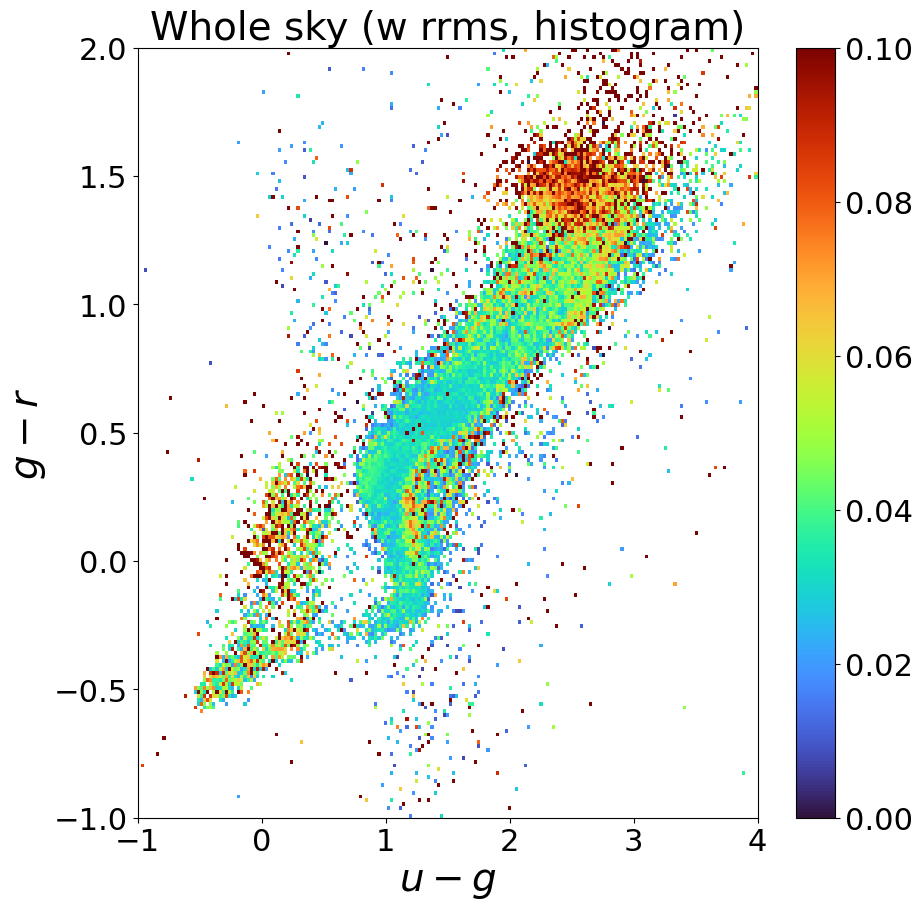

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

S_cc = 1
WR_MAX = 0.1
WR_MIN = 0.0

ax.set_xlabel('$u-g$')
ax.set_ylabel('$g-r$')
ax.set_xlim(-1, 4)
ax.set_ylim(-1, 2)
ax.set_title('Whole sky (w rrms, histogram)')


bins_gMr = np.linspace(-1, 2, RES*2)
bins_uMg = np.linspace(-1, 4, RES*2)
hist_median = np.histogram2d(uMg(DF), gMr(DF), bins=(bins_uMg, bins_gMr), weights=DF[SGW_COLNAME])[0]/hist

sc = ax.pcolormesh(bins_uMg, bins_gMr, hist_median.T, cmap='turbo', norm='linear', vmin=WR_MIN, vmax=WR_MAX)

# sc = ax.scatter(uMg(DF), gMr(DF), s=S_cc, label='all', alpha=0.8,
#                 cmap='BrBG', c=DF[W_MEDIAN_COLNAME], vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)

plt.savefig('../figures/cc_whole_sky_histogram_rrms.png', dpi=600)

plt.show()

# 2nd mode

In [15]:
LIM_MODE_RMS_UPPER = 0.065
LIM_MODE_MED_LOWER = 0.66
LIM_MODE_MED_UPPER = 0.79
LIM_RMS_LOWER = 0.1
LIM_RMS_UPPER = 0.2


def ww_region_rms(df):
    x = df['w_rrms']
    y = df['w_median']
    
    conditions = [
        (x < LIM_MODE_RMS_UPPER) & (y < LIM_MODE_MED_UPPER) & (y > LIM_MODE_MED_LOWER),
        (x < LIM_RMS_UPPER) & (x > LIM_RMS_LOWER),
        (x > LIM_RMS_UPPER)
    ]
    choices = [ 1, 2, 3 ]
    
    return np.select(conditions, choices, default=7)

In [71]:
def line(p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    a = (y2-y1)/(x2-x1)
    b = y1 - a*x1
    return lambda x: a * x + b


def cc_region(df):
    line_lower = line((0.7, 0.1), (3.7, 1.5))
    line_upper = line((0.7, 0.5), (2.0, 1.1))
    x = df['psfMag_u'] - df['psfMag_g']
    y = df['psfMag_g'] - df['psfMag_r']
    
    lux, llx = line_upper(x), line_lower(x)
    
    conditions = [
        (x < 0.7) & (y < -0.2),
        (x < 0.7) & (-0.2 <= y) & (y <= 0.5),
        (x < 0.7) & (y > 0.5),
        (x < 2.0) & (y > lux),
        (0.7 <= x) & (x <= 1.4) & (y < llx),
        (0.7 <= x) & (x <= 1.4) & (y > llx) & (y < lux),
        (1.4 < x) & (x < 2.0) & (y > llx) & (y < lux),
        (x >= 2.0) & (y > llx)        
    ]
    choices = [ 1, 2, 3, 3, 4, 5, 6, 7 ]
    
    return np.select(conditions, choices, default=8)


cc_region_names = [ 'I', 'II', 'III', 'IV', 'Va', 'Vb', 'Vc', 'VI' ]

In [16]:
DF['wwr'] = ww_region_rms(DF)
df1 = DF[DF.wwr == 1]
df2 = DF[DF.wwr == 2]
df3 = DF[DF.wwr == 3]

In [73]:
DF['ccr'] = cc_region(DF)

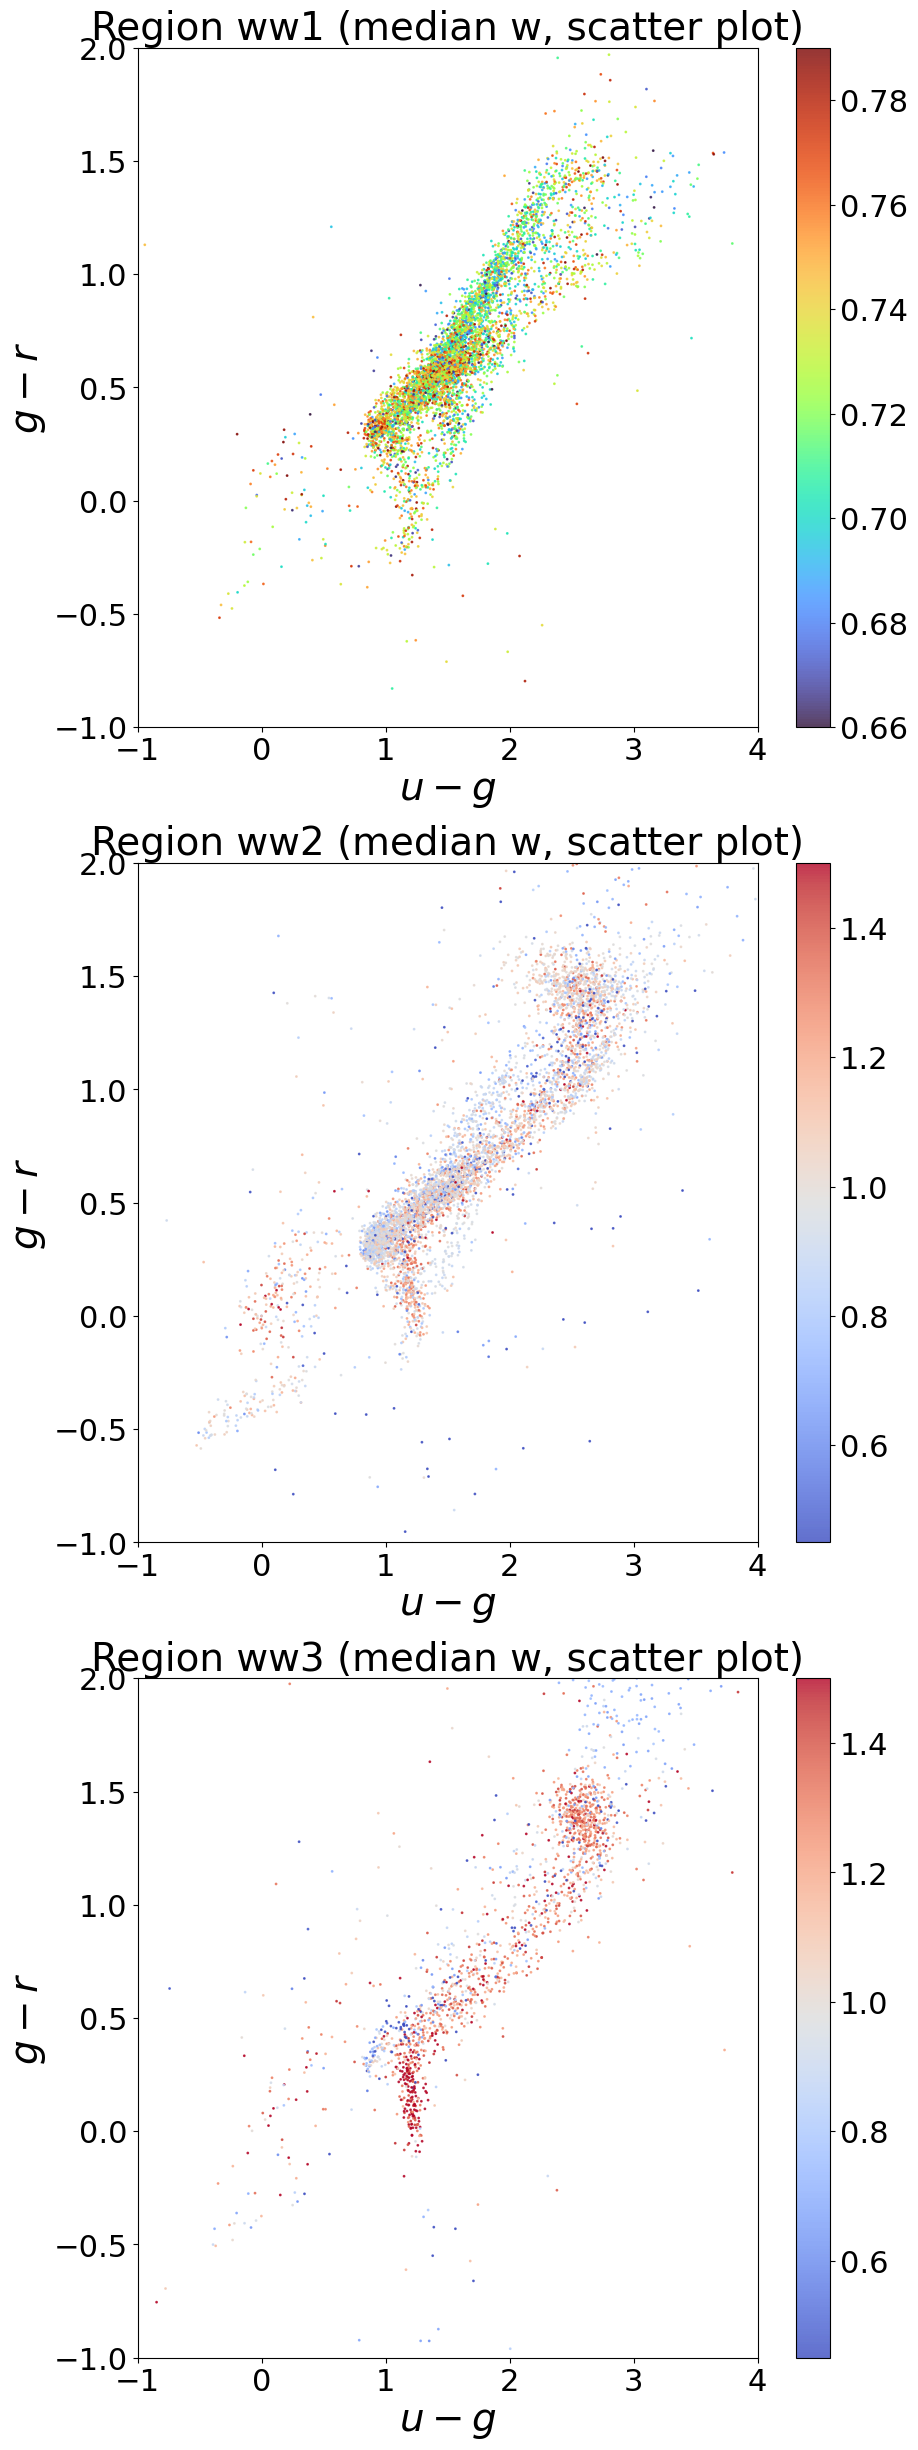

In [17]:
fig, ax = plt.subplots(3, 1, figsize=(10, 30))

S_cc = 1
W_MAX = LIM_MODE_MED_UPPER
W_MIN = LIM_MODE_MED_LOWER


ax[0].set_xlabel('$u-g$')
ax[0].set_ylabel('$g-r$')
ax[0].set_xlim(-1, 4)
ax[0].set_ylim(-1, 2)
ax[0].set_title('Region ww1 (median w, scatter plot)')

sc = ax[0].scatter(uMg(df1), gMr(df1), s=S_cc, label='all', alpha=0.8,
                   cmap='turbo', c=df1[W_MEDIAN_COLNAME], vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)


#
W_MAX = 0.5
W_MIN = 1.5

ax[1].set_xlabel('$u-g$')
ax[1].set_ylabel('$g-r$')
ax[1].set_xlim(-1, 4)
ax[1].set_ylim(-1, 2)
ax[1].set_title('Region ww2 (median w, scatter plot)')

sc = ax[1].scatter(uMg(df2), gMr(df2), s=S_cc, label='all', alpha=0.8,
                   cmap='coolwarm', c=df2[W_MEDIAN_COLNAME], vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)


ax[2].set_xlabel('$u-g$')
ax[2].set_ylabel('$g-r$')
ax[2].set_xlim(-1, 4)
ax[2].set_ylim(-1, 2)
ax[2].set_title('Region ww3 (median w, scatter plot)')

sc = ax[2].scatter(uMg(df3), gMr(df3), s=S_cc, label='all', alpha=0.8,
                   cmap='coolwarm', c=df3[W_MEDIAN_COLNAME], vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)

plt.savefig('../figures/cc_regions_scatter.png', dpi=600)

plt.show()

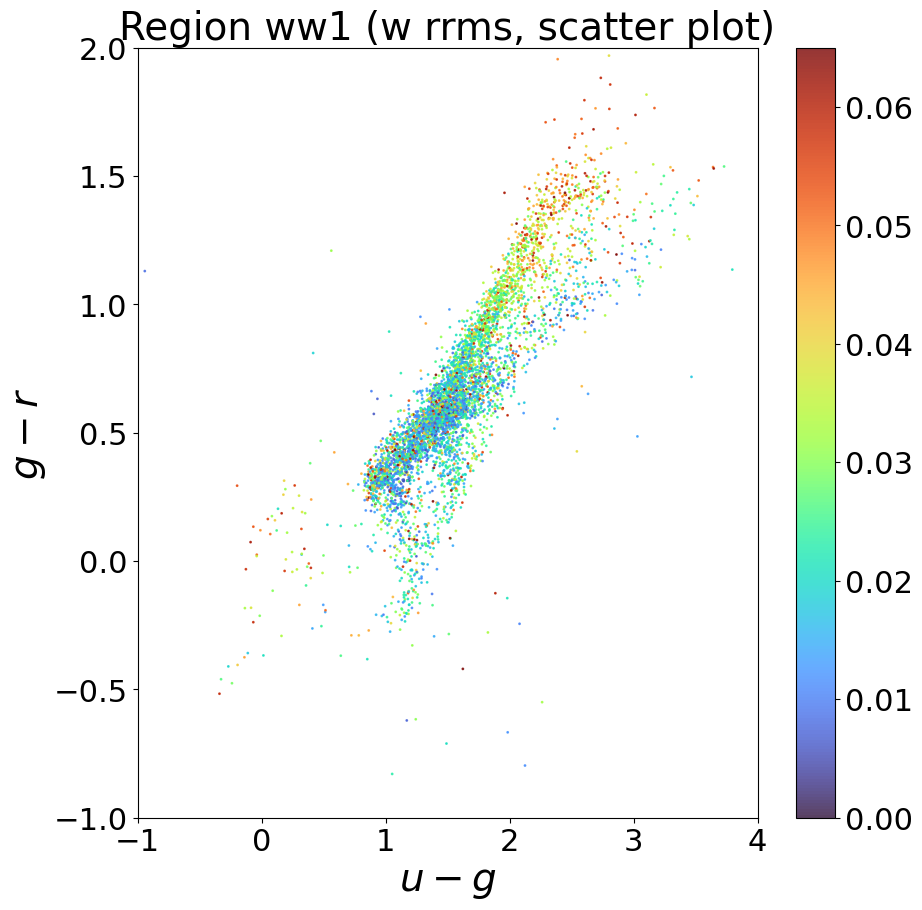

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

S_cc = 1
WR_MAX = LIM_MODE_RMS_UPPER
WR_MIN = 0.0

ax.set_xlabel('$u-g$')
ax.set_ylabel('$g-r$')
ax.set_xlim(-1, 4)
ax.set_ylim(-1, 2)
ax.set_title('Region ww1 (w rrms, scatter plot)')

sc = ax.scatter(uMg(df1), gMr(df1), s=S_cc, label='all', alpha=0.8,
                cmap='turbo', c=df1[SGW_COLNAME], vmin=WR_MIN, vmax=WR_MAX)
plt.colorbar(sc)

plt.savefig('../figures/cc_region1_scatter_rrms_mode2.png', dpi=600)

plt.show()

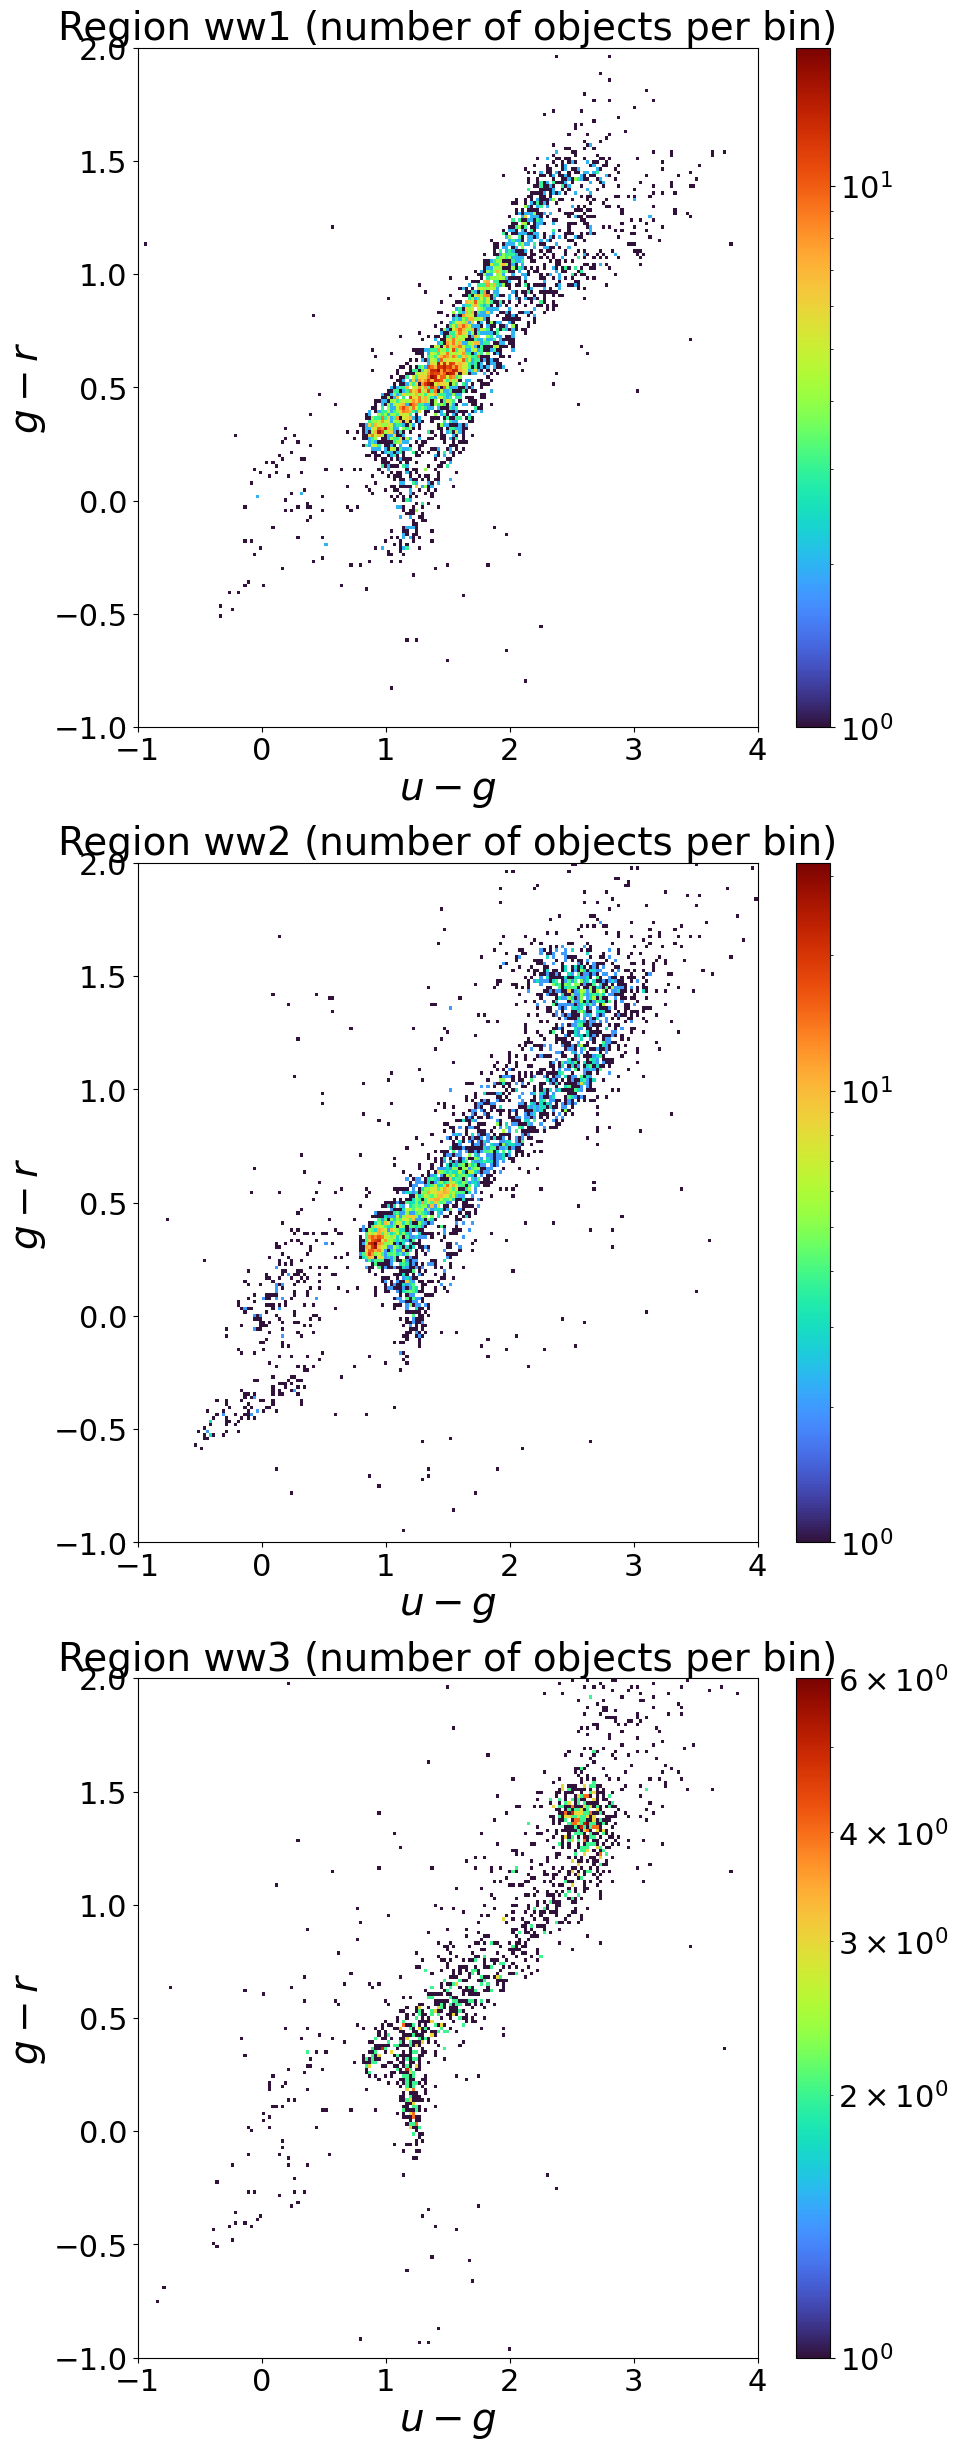

In [19]:
fig, ax = plt.subplots(3, 1, figsize=(10, 30))

S_cc = 1

ax[0].set_xlabel('$u-g$')
ax[0].set_ylabel('$g-r$')
ax[0].set_xlim(-1, 4)
ax[0].set_ylim(-1, 2)
ax[0].set_title('Region ww1 (number of objects per bin)')


bins_gMr = np.linspace(-1, 2, RES*2)
bins_uMg = np.linspace(-1, 4, RES*2)
hist1, _, _ = np.histogram2d(uMg(df1), gMr(df1), bins=(bins_uMg, bins_gMr))

sc = ax[0].pcolormesh(bins_uMg, bins_gMr, hist1.T, cmap='turbo', norm='log')

# sc = ax.scatter(uMg(DF), gMr(DF), s=S_cc, label='all', alpha=0.8,
#                 cmap='BrBG', c=DF[W_MEDIAN_COLNAME], vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)


ax[1].set_xlabel('$u-g$')
ax[1].set_ylabel('$g-r$')
ax[1].set_xlim(-1, 4)
ax[1].set_ylim(-1, 2)
ax[1].set_title('Region ww2 (number of objects per bin)')


bins_gMr = np.linspace(-1, 2, RES*2)
bins_uMg = np.linspace(-1, 4, RES*2)
hist2, _, _ = np.histogram2d(uMg(df2), gMr(df2), bins=(bins_uMg, bins_gMr))

sc = ax[1].pcolormesh(bins_uMg, bins_gMr, hist2.T, cmap='turbo', norm='log')

# sc = ax.scatter(uMg(DF), gMr(DF), s=S_cc, label='all', alpha=0.8,
#                 cmap='BrBG', c=DF[W_MEDIAN_COLNAME], vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)


ax[2].set_xlabel('$u-g$')
ax[2].set_ylabel('$g-r$')
ax[2].set_xlim(-1, 4)
ax[2].set_ylim(-1, 2)
ax[2].set_title('Region ww3 (number of objects per bin)')


bins_gMr = np.linspace(-1, 2, RES*2)
bins_uMg = np.linspace(-1, 4, RES*2)
hist3, _, _ = np.histogram2d(uMg(df3), gMr(df3), bins=(bins_uMg, bins_gMr))

sc = ax[2].pcolormesh(bins_uMg, bins_gMr, hist3.T, cmap='turbo', norm='log')

# sc = ax.scatter(uMg(DF), gMr(DF), s=S_cc, label='all', alpha=0.8,
#                 cmap='BrBG', c=DF[W_MEDIAN_COLNAME], vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)



plt.savefig('../figures/cc_regions_histogram_number.png', dpi=600)

plt.show()

/tmp/ipykernel_505742/3354890044.py:16: RuntimeWarning: invalid value encountered in divide
  hist_median = np.histogram2d(uMg(df1), gMr(df1), bins=(bins_uMg, bins_gMr), weights=df1[W_MEDIAN_COLNAME])[0]/hist1
/tmp/ipykernel_505742/3354890044.py:32: RuntimeWarning: invalid value encountered in divide
  hist_median = np.histogram2d(uMg(df2), gMr(df2), bins=(bins_uMg, bins_gMr), weights=df2[W_MEDIAN_COLNAME])[0]/hist2
/tmp/ipykernel_505742/3354890044.py:44: RuntimeWarning: invalid value encountered in divide
  hist_median = np.histogram2d(uMg(df3), gMr(df3), bins=(bins_uMg, bins_gMr), weights=df3[W_MEDIAN_COLNAME])[0]/hist3


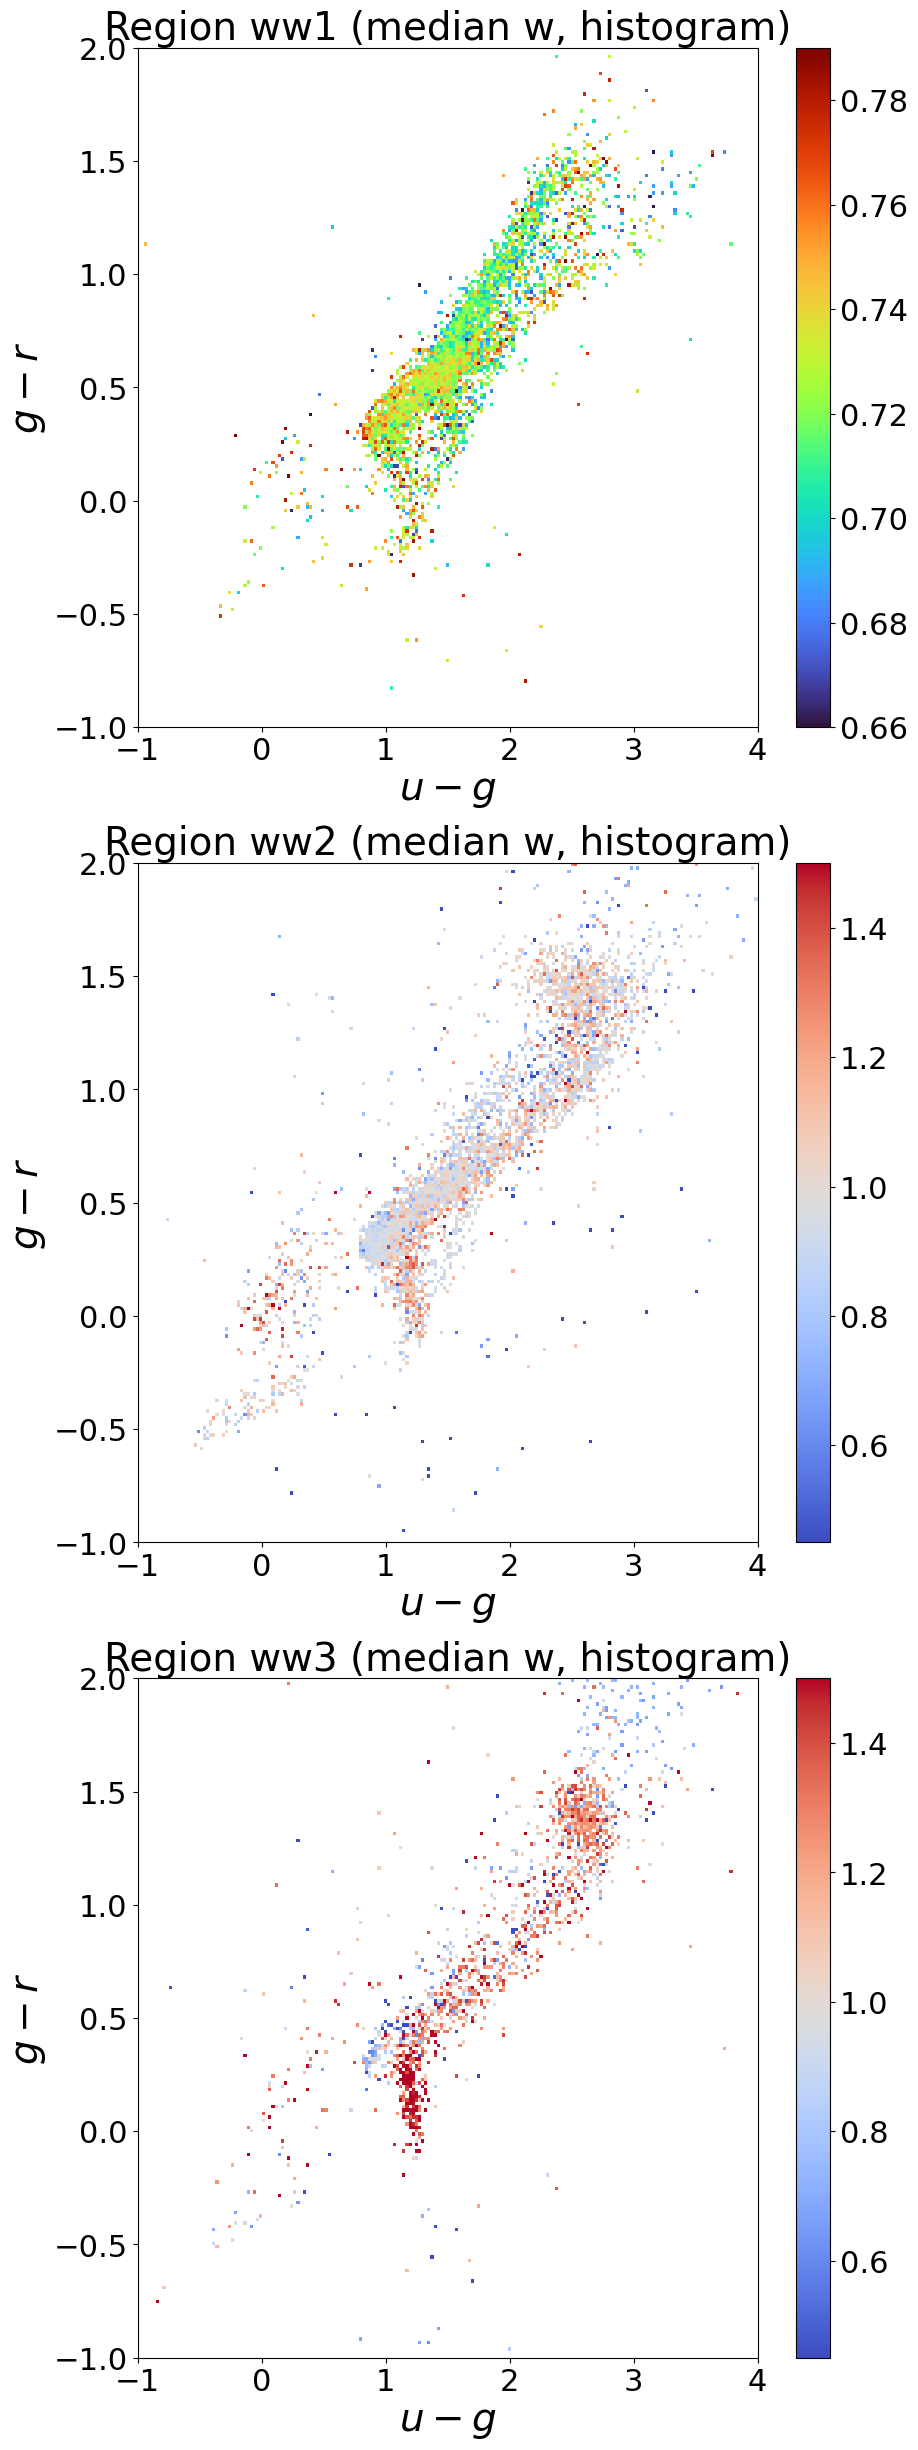

In [20]:
fig, ax = plt.subplots(3, 1, figsize=(10, 30))

S_cc = 1
W_MAX = LIM_MODE_MED_UPPER
W_MIN = LIM_MODE_MED_LOWER


ax[0].set_xlabel('$u-g$')
ax[0].set_ylabel('$g-r$')
ax[0].set_xlim(-1, 4)
ax[0].set_ylim(-1, 2)
ax[0].set_title('Region ww1 (median w, histogram)')

bins_gMr = np.linspace(-1, 2, RES*2)
bins_uMg = np.linspace(-1, 4, RES*2)
hist_median = np.histogram2d(uMg(df1), gMr(df1), bins=(bins_uMg, bins_gMr), weights=df1[W_MEDIAN_COLNAME])[0]/hist1

sc = ax[0].pcolormesh(bins_uMg, bins_gMr, hist_median.T, cmap='turbo', norm='linear', vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)


#
W_MAX = 0.5
W_MIN = 1.5

ax[1].set_xlabel('$u-g$')
ax[1].set_ylabel('$g-r$')
ax[1].set_xlim(-1, 4)
ax[1].set_ylim(-1, 2)
ax[1].set_title('Region ww2 (median w, histogram)')

hist_median = np.histogram2d(uMg(df2), gMr(df2), bins=(bins_uMg, bins_gMr), weights=df2[W_MEDIAN_COLNAME])[0]/hist2

sc = ax[1].pcolormesh(bins_uMg, bins_gMr, hist_median.T, cmap='coolwarm', norm='linear', vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)


ax[2].set_xlabel('$u-g$')
ax[2].set_ylabel('$g-r$')
ax[2].set_xlim(-1, 4)
ax[2].set_ylim(-1, 2)
ax[2].set_title('Region ww3 (median w, histogram)')

hist_median = np.histogram2d(uMg(df3), gMr(df3), bins=(bins_uMg, bins_gMr), weights=df3[W_MEDIAN_COLNAME])[0]/hist3

sc = ax[2].pcolormesh(bins_uMg, bins_gMr, hist_median.T, cmap='coolwarm', norm='linear', vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)

plt.savefig('../figures/cc_regions_histogram_median.png', dpi=600)

plt.show()

/tmp/ipykernel_505742/1661885062.py:16: RuntimeWarning: invalid value encountered in divide
  hist_median = np.histogram2d(uMg(df1), gMr(df1), bins=(bins_uMg, bins_gMr), weights=df1[SGW_COLNAME])[0]/hist1


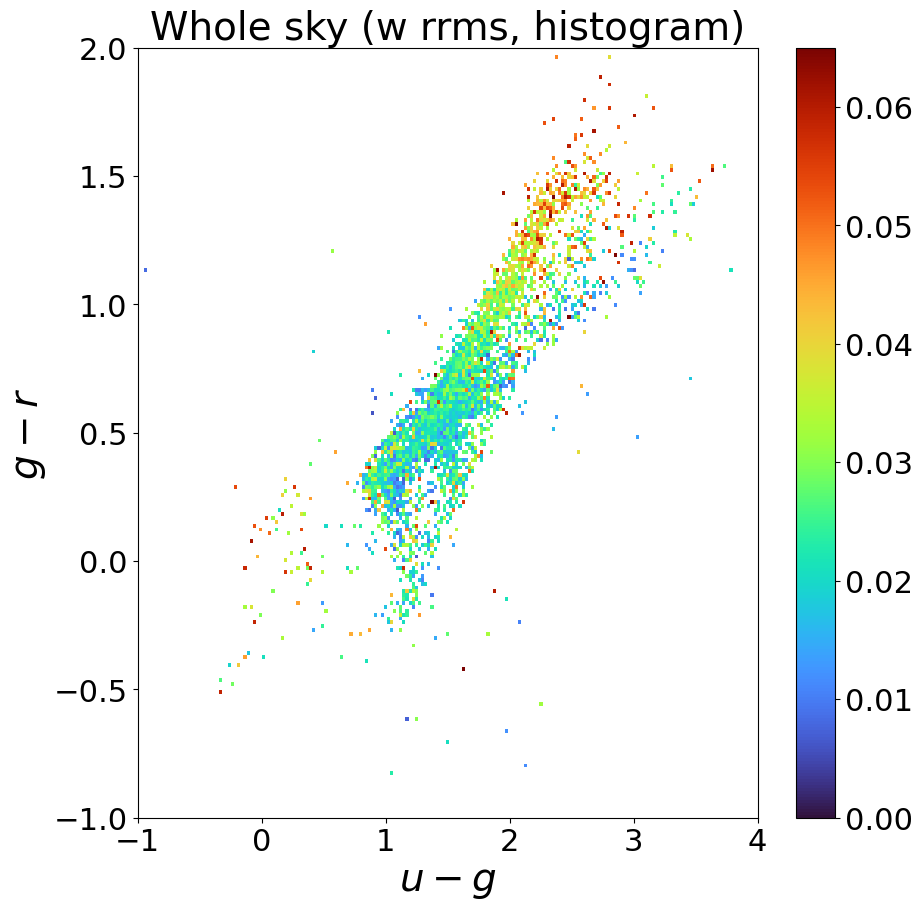

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

S_cc = 1
WR_MAX = LIM_MODE_RMS_UPPER
WR_MIN = 0.0

ax.set_xlabel('$u-g$')
ax.set_ylabel('$g-r$')
ax.set_xlim(-1, 4)
ax.set_ylim(-1, 2)
ax.set_title('Whole sky (w rrms, histogram)')


bins_gMr = np.linspace(-1, 2, RES*2)
bins_uMg = np.linspace(-1, 4, RES*2)
hist_median = np.histogram2d(uMg(df1), gMr(df1), bins=(bins_uMg, bins_gMr), weights=df1[SGW_COLNAME])[0]/hist1

sc = ax.pcolormesh(bins_uMg, bins_gMr, hist_median.T, cmap='turbo', norm='linear', vmin=WR_MIN, vmax=WR_MAX)

# sc = ax.scatter(uMg(DF), gMr(DF), s=S_cc, label='all', alpha=0.8,
#                 cmap='BrBG', c=DF[W_MEDIAN_COLNAME], vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)

plt.savefig('../figures/cc_region1_histogram_rrms.png', dpi=600)

plt.show()

## BP std

In [22]:
BP_STD_COLNAME = 'bp_standard_deviation'
RP_STD_COLNAME = 'rp_standard_deviation'

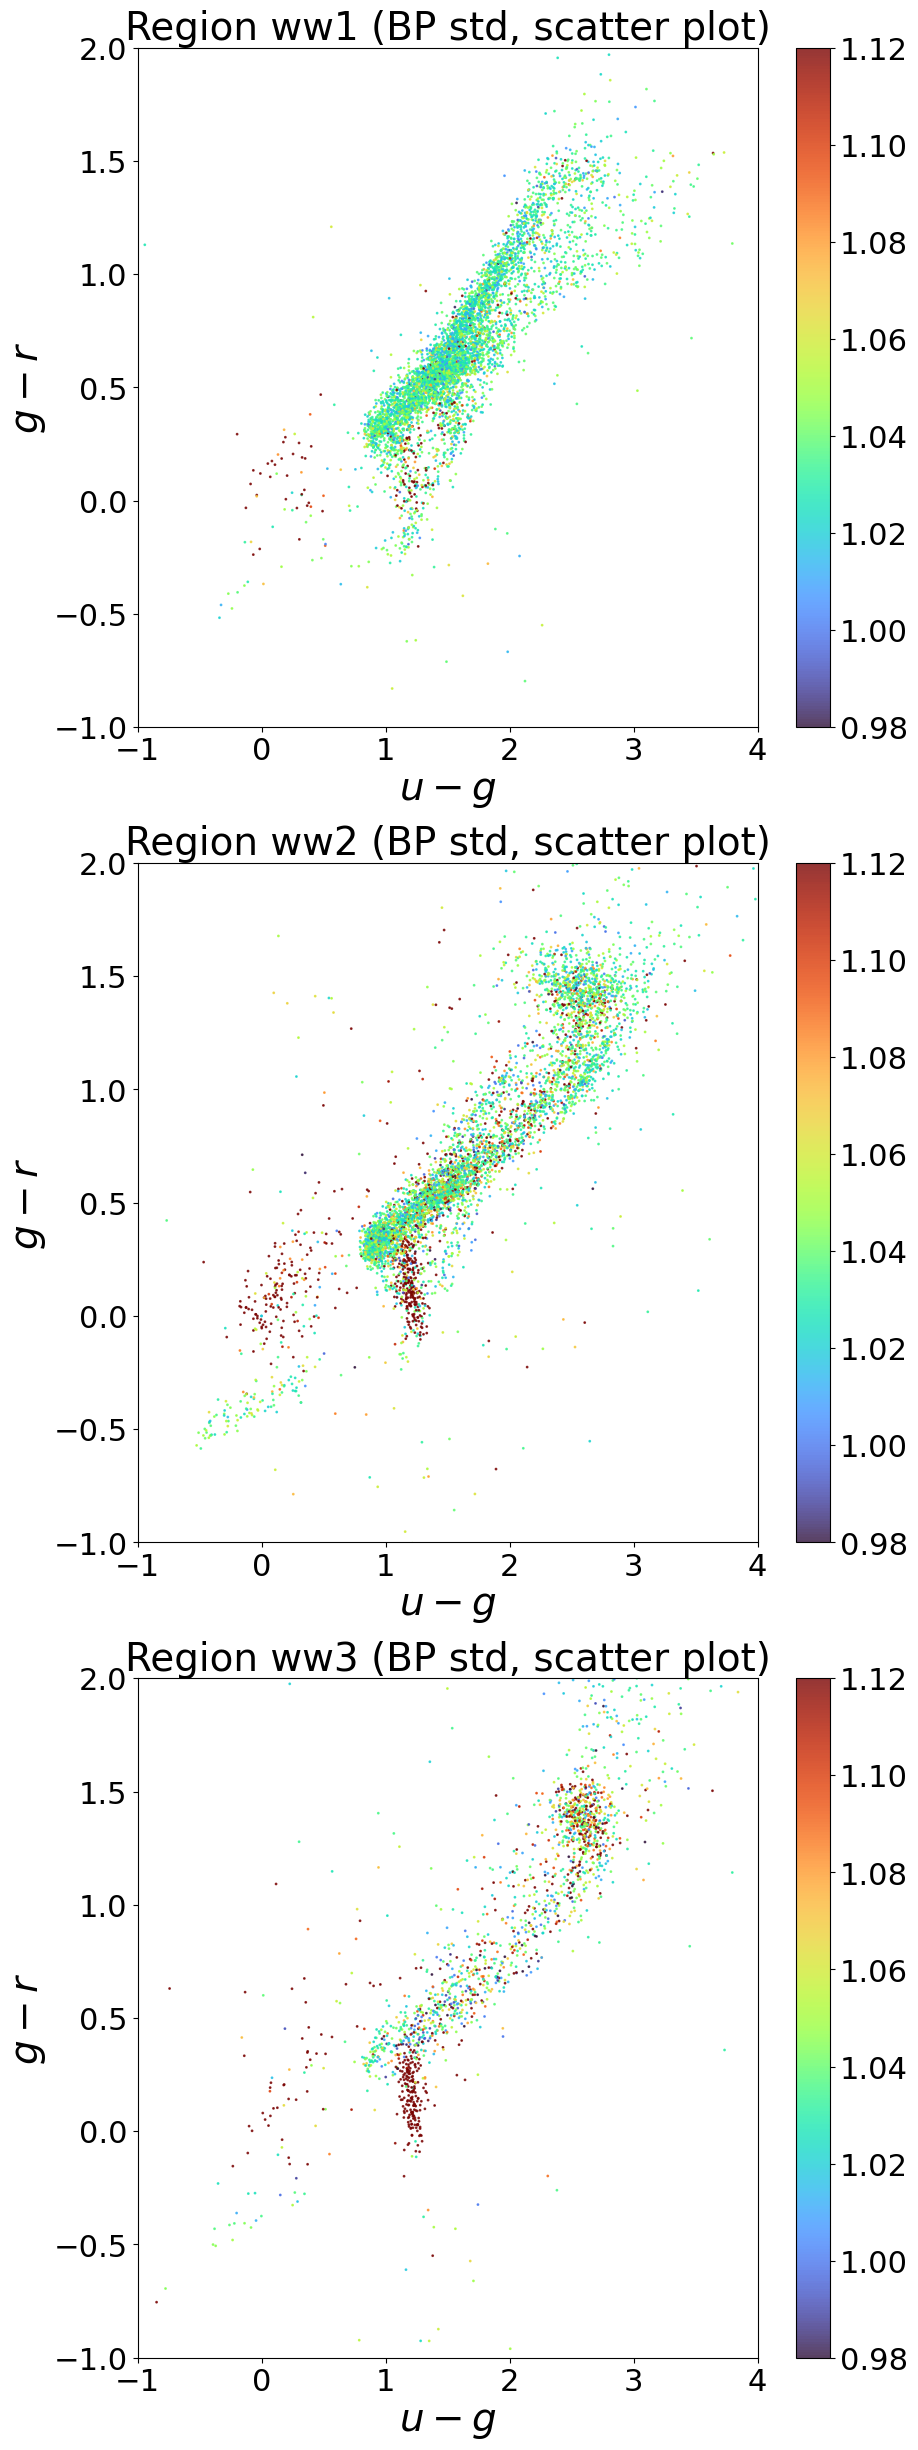

In [23]:
fig, ax = plt.subplots(3, 1, figsize=(10, 30))

S_cc = 1
W_MIN = 0.98
W_MAX = 1.12


ax[0].set_xlabel('$u-g$')
ax[0].set_ylabel('$g-r$')
ax[0].set_xlim(-1, 4)
ax[0].set_ylim(-1, 2)
ax[0].set_title('Region ww1 (BP std, scatter plot)')

sc = ax[0].scatter(uMg(df1), gMr(df1), s=S_cc, label='all', alpha=0.8,
                   cmap='turbo', c=df1[BP_STD_COLNAME], vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)


#

ax[1].set_xlabel('$u-g$')
ax[1].set_ylabel('$g-r$')
ax[1].set_xlim(-1, 4)
ax[1].set_ylim(-1, 2)
ax[1].set_title('Region ww2 (BP std, scatter plot)')

sc = ax[1].scatter(uMg(df2), gMr(df2), s=S_cc, label='all', alpha=0.8,
                   cmap='turbo', c=df2[BP_STD_COLNAME], vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)


ax[2].set_xlabel('$u-g$')
ax[2].set_ylabel('$g-r$')
ax[2].set_xlim(-1, 4)
ax[2].set_ylim(-1, 2)
ax[2].set_title('Region ww3 (BP std, scatter plot)')

sc = ax[2].scatter(uMg(df3), gMr(df3), s=S_cc, label='all', alpha=0.8,
                   cmap='turbo', c=df3[BP_STD_COLNAME], vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)

plt.savefig('../figures/cc_regions_scatter_bp_std.png', dpi=600)

plt.show()

/tmp/ipykernel_505742/1912220564.py:16: RuntimeWarning: invalid value encountered in divide
  hist_median = np.histogram2d(uMg(df1), gMr(df1), bins=(bins_uMg, bins_gMr), weights=df1[BP_STD_COLNAME])[0]/hist1
/tmp/ipykernel_505742/1912220564.py:30: RuntimeWarning: invalid value encountered in divide
  hist_median = np.histogram2d(uMg(df2), gMr(df2), bins=(bins_uMg, bins_gMr), weights=df2[BP_STD_COLNAME])[0]/hist2
/tmp/ipykernel_505742/1912220564.py:42: RuntimeWarning: invalid value encountered in divide
  hist_median = np.histogram2d(uMg(df3), gMr(df3), bins=(bins_uMg, bins_gMr), weights=df3[BP_STD_COLNAME])[0]/hist3


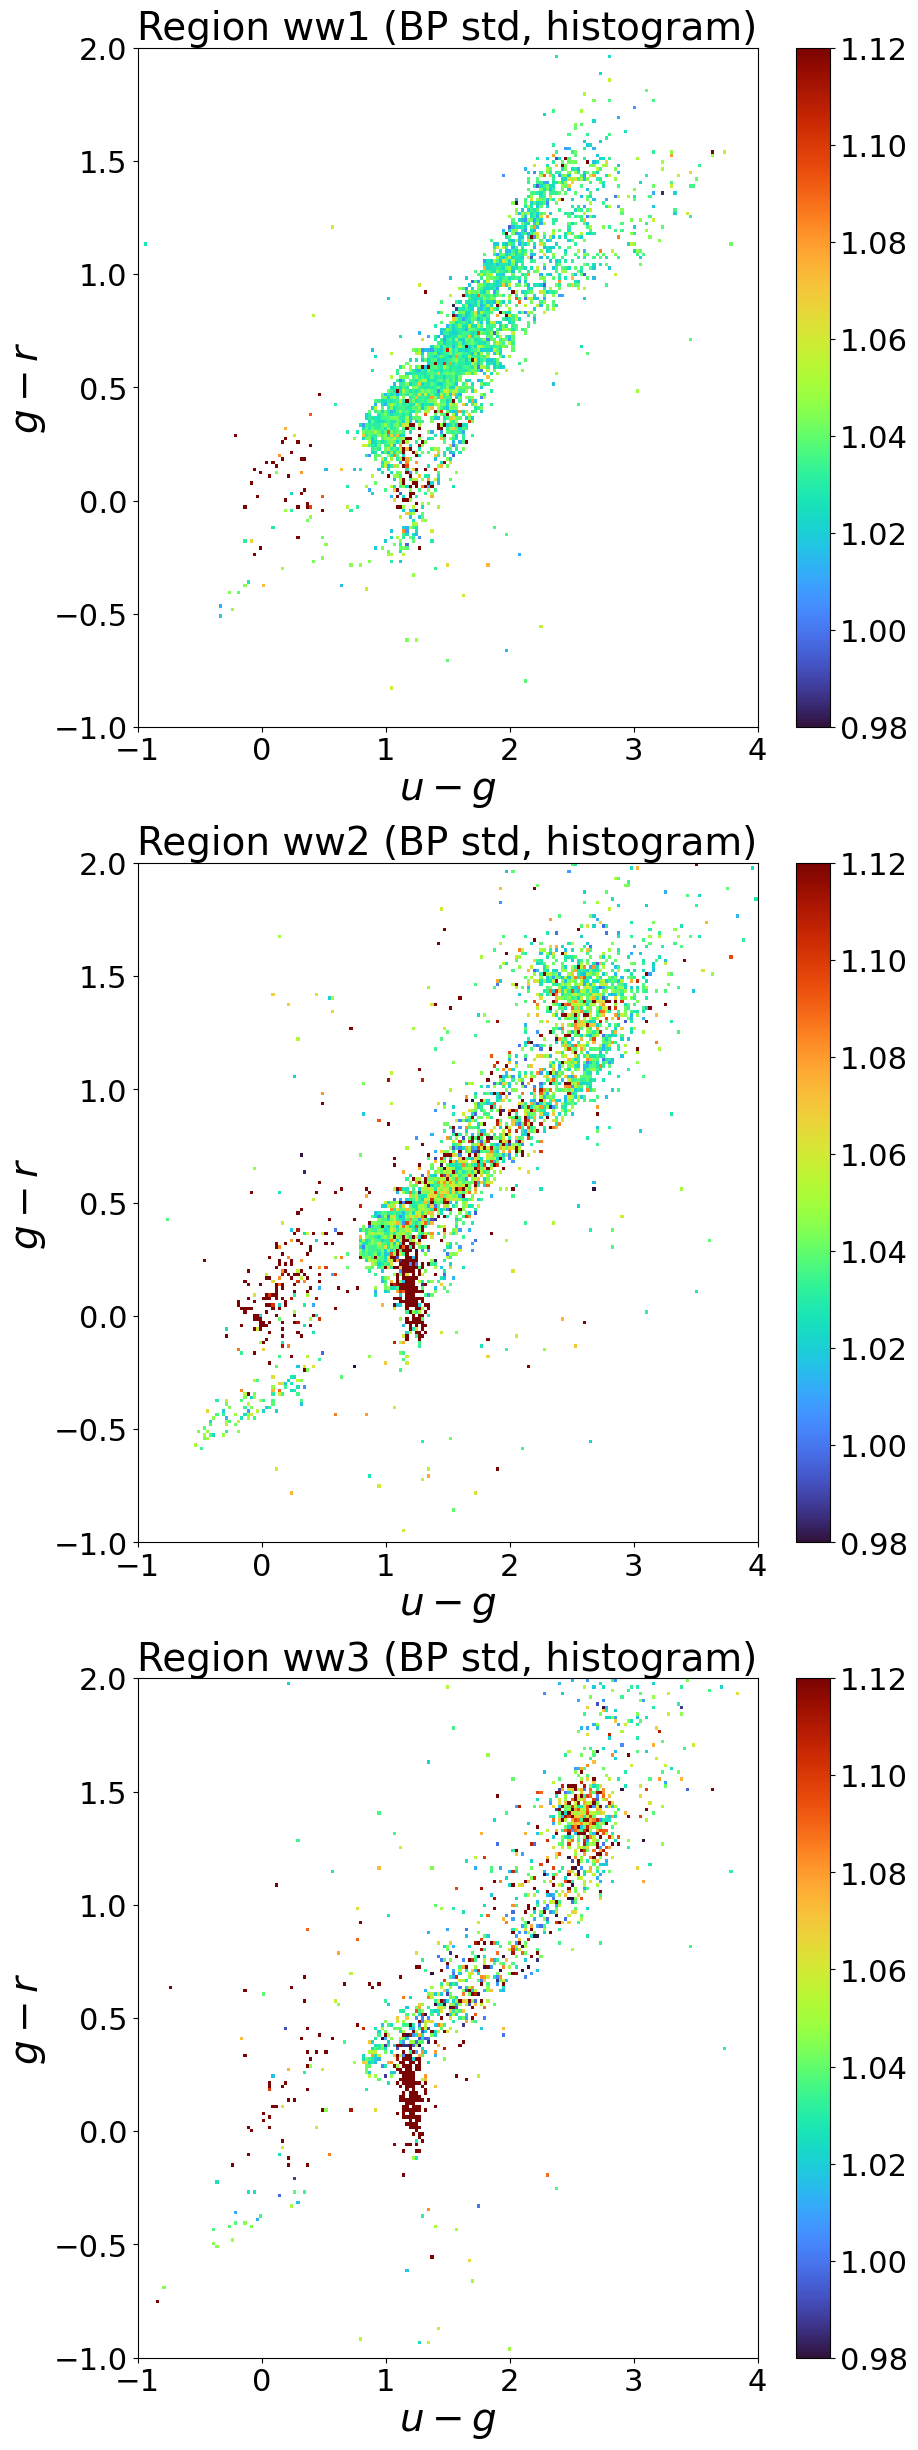

In [24]:
fig, ax = plt.subplots(3, 1, figsize=(10, 30))

S_cc = 1
W_MIN = 0.98
W_MAX = 1.12


ax[0].set_xlabel('$u-g$')
ax[0].set_ylabel('$g-r$')
ax[0].set_xlim(-1, 4)
ax[0].set_ylim(-1, 2)
ax[0].set_title('Region ww1 (BP std, histogram)')

bins_gMr = np.linspace(-1, 2, RES*2)
bins_uMg = np.linspace(-1, 4, RES*2)
hist_median = np.histogram2d(uMg(df1), gMr(df1), bins=(bins_uMg, bins_gMr), weights=df1[BP_STD_COLNAME])[0]/hist1

sc = ax[0].pcolormesh(bins_uMg, bins_gMr, hist_median.T, cmap='turbo', norm='linear', vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)


#

ax[1].set_xlabel('$u-g$')
ax[1].set_ylabel('$g-r$')
ax[1].set_xlim(-1, 4)
ax[1].set_ylim(-1, 2)
ax[1].set_title('Region ww2 (BP std, histogram)')

hist_median = np.histogram2d(uMg(df2), gMr(df2), bins=(bins_uMg, bins_gMr), weights=df2[BP_STD_COLNAME])[0]/hist2

sc = ax[1].pcolormesh(bins_uMg, bins_gMr, hist_median.T, cmap='turbo', norm='linear', vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)


ax[2].set_xlabel('$u-g$')
ax[2].set_ylabel('$g-r$')
ax[2].set_xlim(-1, 4)
ax[2].set_ylim(-1, 2)
ax[2].set_title('Region ww3 (BP std, histogram)')

hist_median = np.histogram2d(uMg(df3), gMr(df3), bins=(bins_uMg, bins_gMr), weights=df3[BP_STD_COLNAME])[0]/hist3

sc = ax[2].pcolormesh(bins_uMg, bins_gMr, hist_median.T, cmap='turbo', norm='linear', vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)

plt.savefig('../figures/cc_regions_histogram_median_bp_std.png', dpi=600)

plt.show()

## RP std

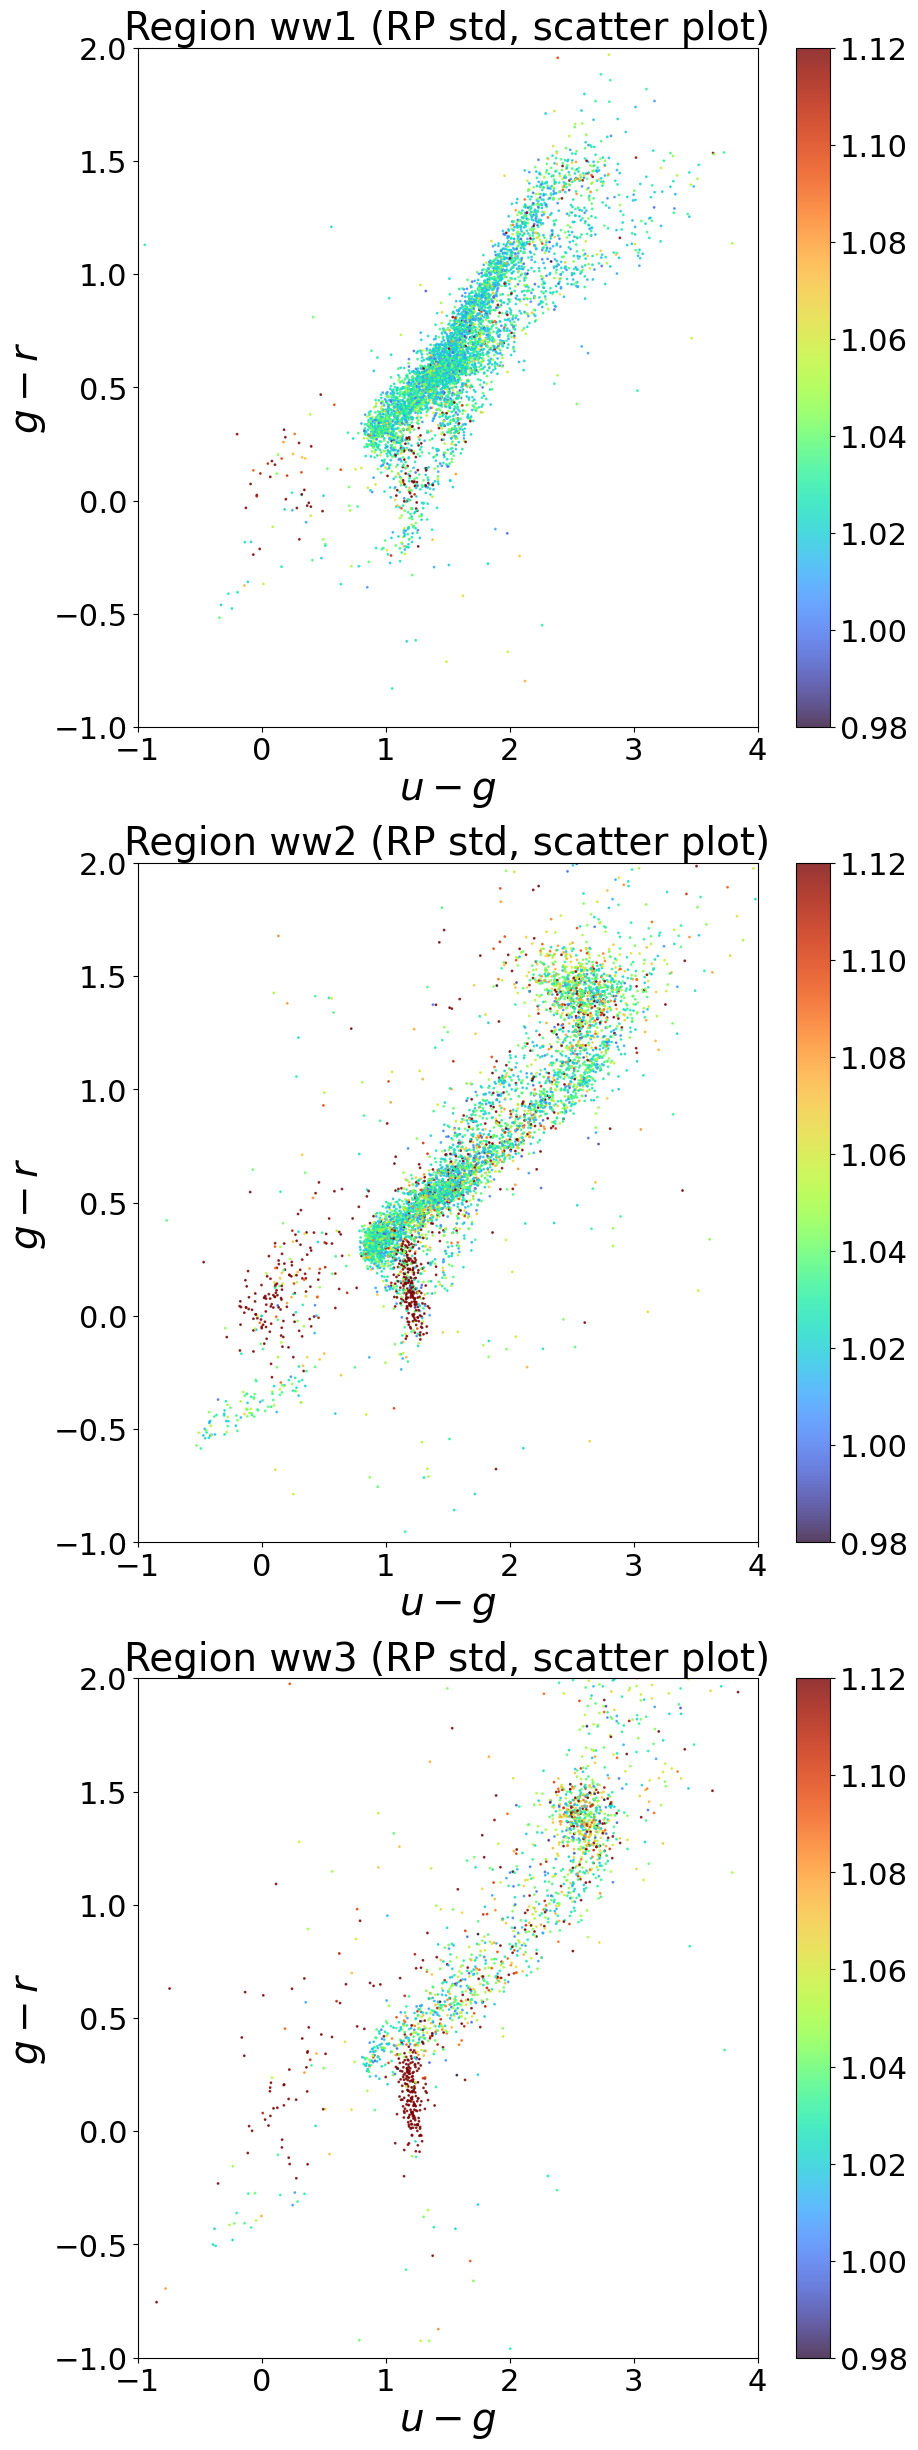

In [25]:
fig, ax = plt.subplots(3, 1, figsize=(10, 30))

S_cc = 1
W_MIN = 0.98
W_MAX = 1.12


ax[0].set_xlabel('$u-g$')
ax[0].set_ylabel('$g-r$')
ax[0].set_xlim(-1, 4)
ax[0].set_ylim(-1, 2)
ax[0].set_title('Region ww1 (RP std, scatter plot)')

sc = ax[0].scatter(uMg(df1), gMr(df1), s=S_cc, label='all', alpha=0.8,
                   cmap='turbo', c=df1[RP_STD_COLNAME], vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)


#

ax[1].set_xlabel('$u-g$')
ax[1].set_ylabel('$g-r$')
ax[1].set_xlim(-1, 4)
ax[1].set_ylim(-1, 2)
ax[1].set_title('Region ww2 (RP std, scatter plot)')

sc = ax[1].scatter(uMg(df2), gMr(df2), s=S_cc, label='all', alpha=0.8,
                   cmap='turbo', c=df2[RP_STD_COLNAME], vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)


ax[2].set_xlabel('$u-g$')
ax[2].set_ylabel('$g-r$')
ax[2].set_xlim(-1, 4)
ax[2].set_ylim(-1, 2)
ax[2].set_title('Region ww3 (RP std, scatter plot)')

sc = ax[2].scatter(uMg(df3), gMr(df3), s=S_cc, label='all', alpha=0.8,
                   cmap='turbo', c=df3[RP_STD_COLNAME], vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)

plt.savefig('../figures/cc_regions_scatter_rp_std.png', dpi=600)

plt.show()

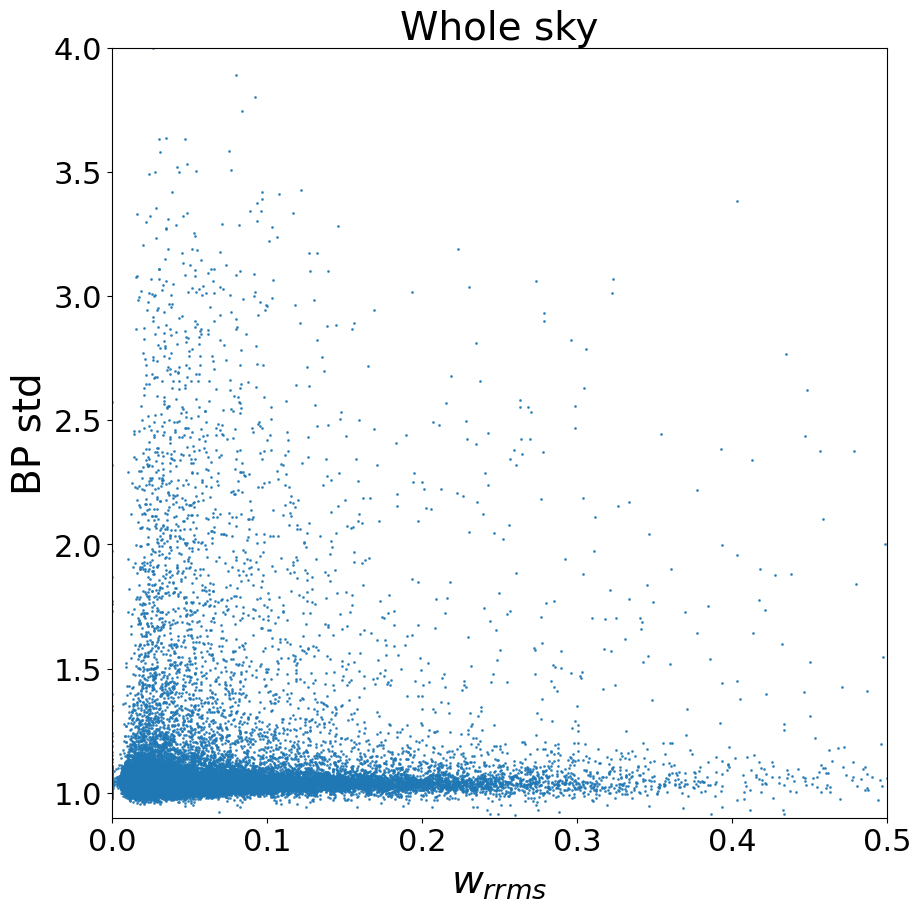

In [87]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

S_cc = 1
W_MIN = 0.98
W_MAX = 1.12


ax.set_xlabel('$w_{rrms}$')
ax.set_ylabel('BP std')
ax.set_xlim(0, 0.5)
ax.set_ylim(0.9, 4)
ax.set_title('Whole sky')
ax.scatter(DF[SGW_COLNAME], DF[BP_STD_COLNAME], s=S_cc, alpha=0.8)


plt.savefig('../figures/bp_std_w_rrms.png', dpi=600)

plt.show()

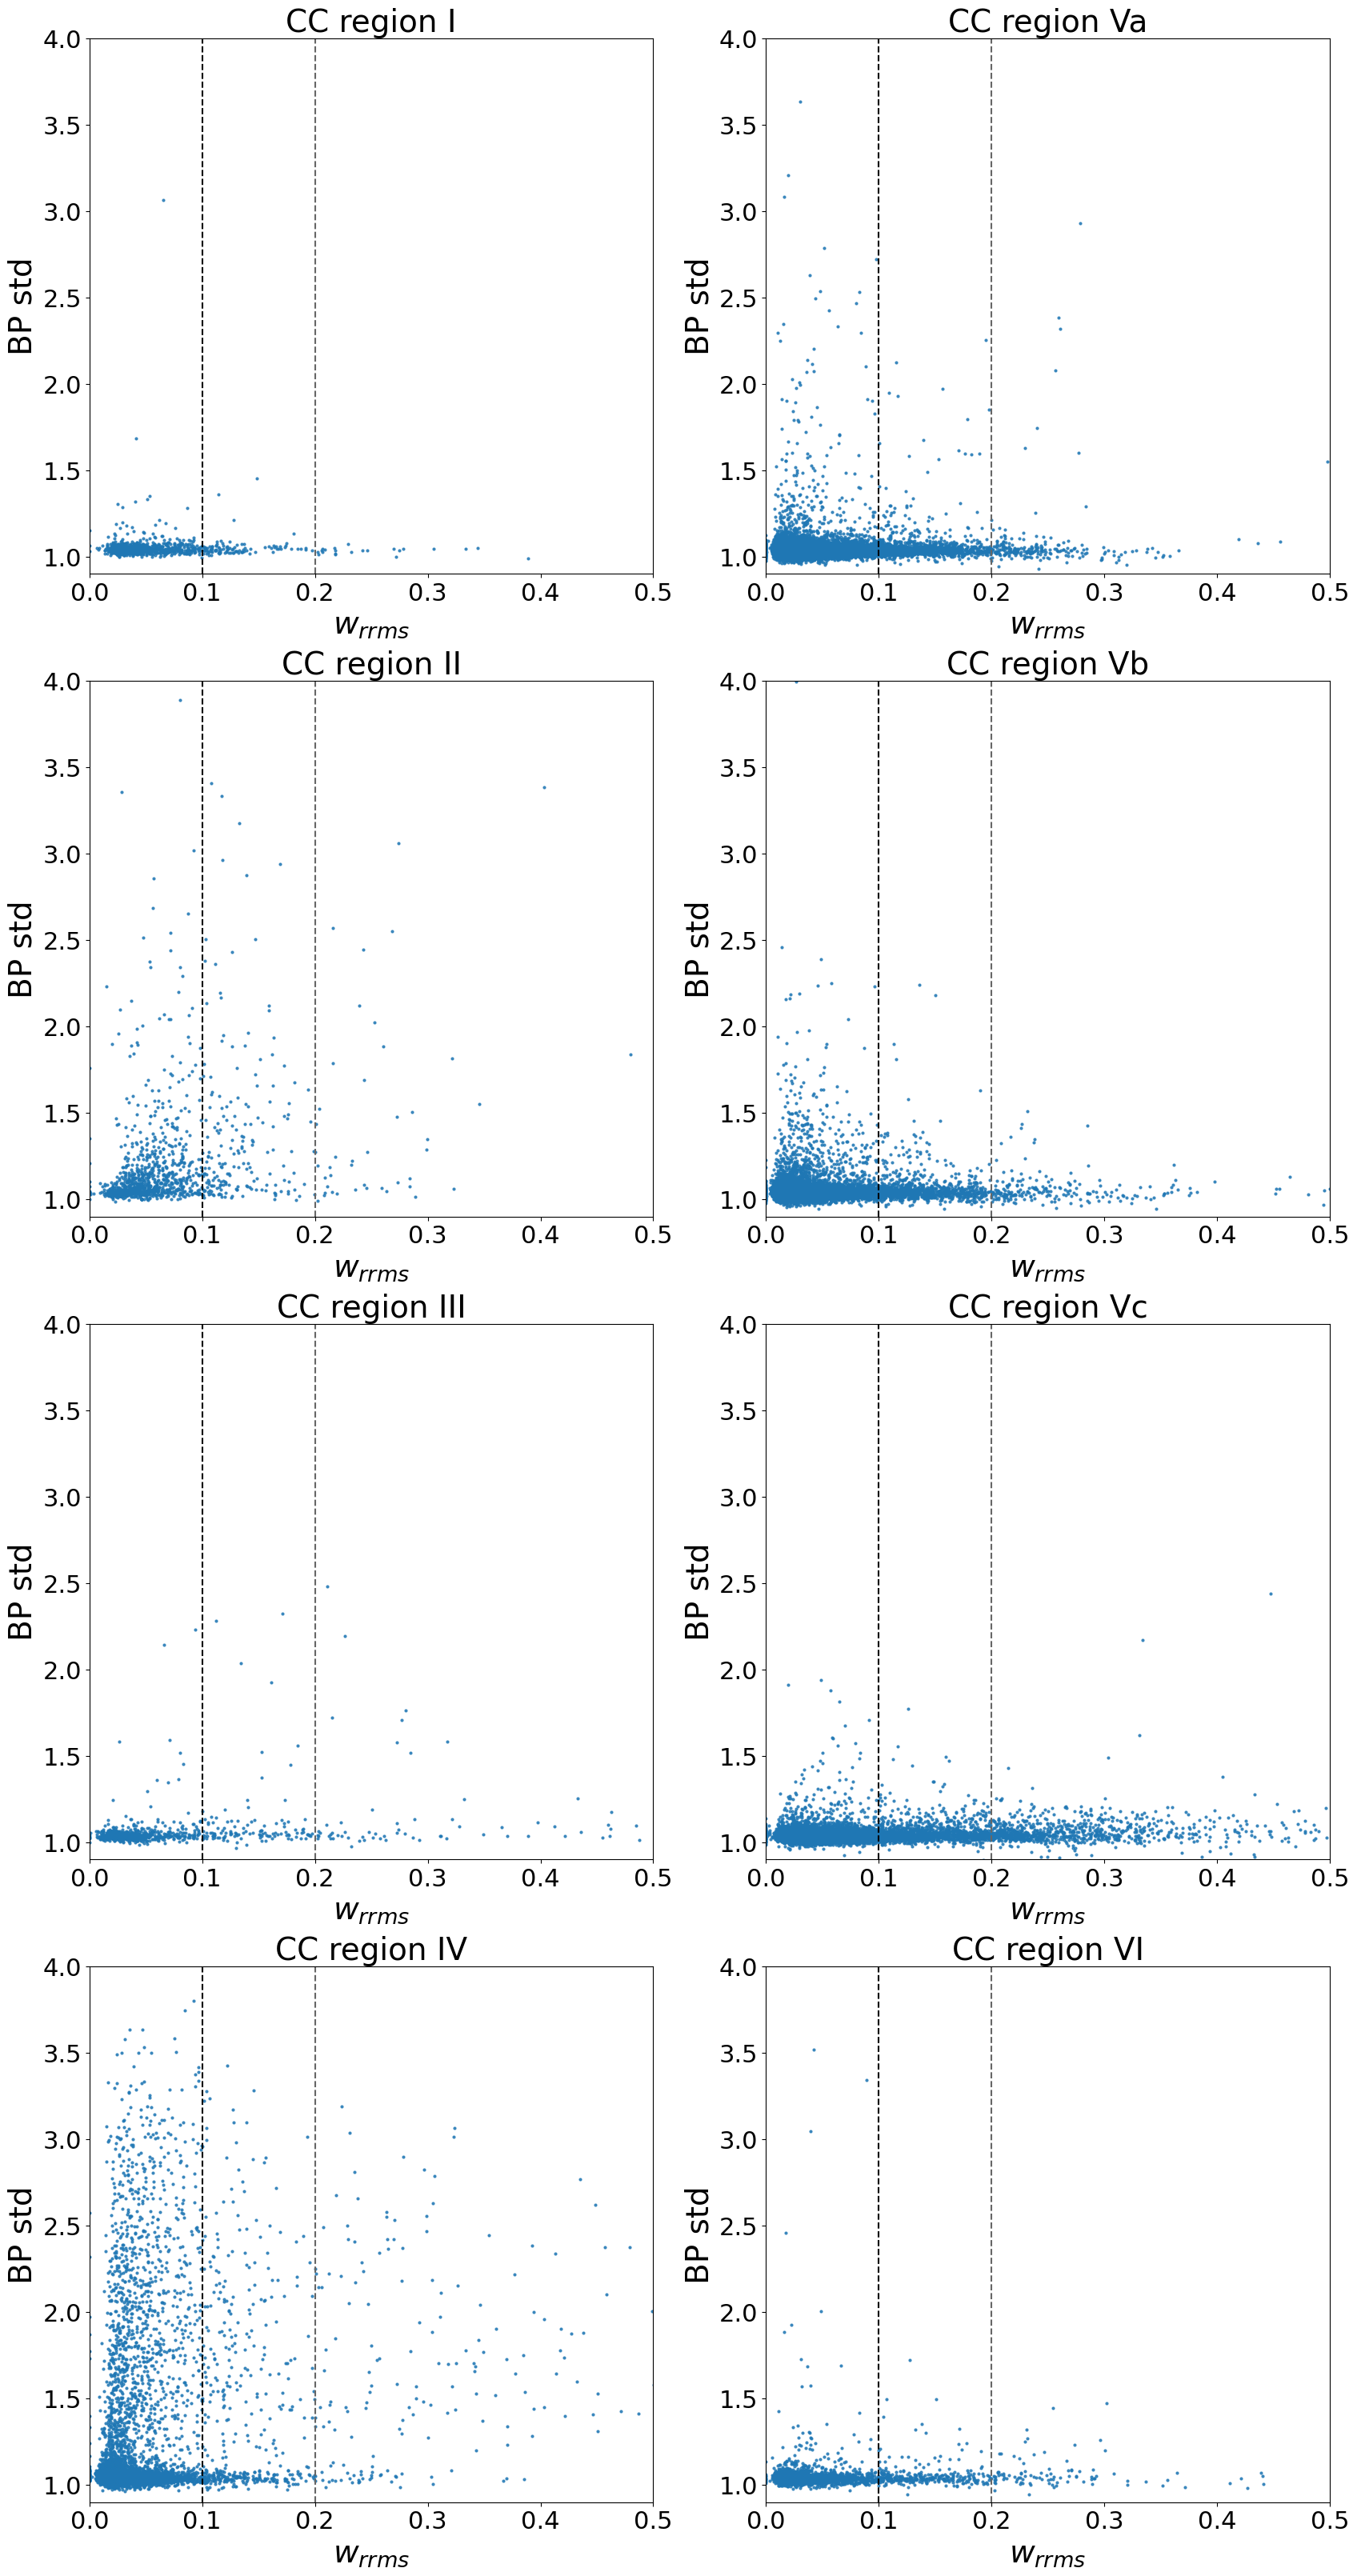

In [85]:
fig, ax = plt.subplots(4, 2, figsize=(20, 40))

S_cc = 4
W_MIN = 0.98
W_MAX = 1.12


for i in range(4):
    for j in range(2):
        df = DF[DF.ccr == 4*j + i + 1]
        ax[i][j].set_xlabel('$w_{rrms}$')
        ax[i][j].set_ylabel('BP std')
        ax[i][j].set_xlim(0, 0.5)
        ax[i][j].set_ylim(0.9, 4)
        ax[i][j].set_title(f'CC region {cc_region_names[4*j+i]}')
        ax[i][j].scatter(df[SGW_COLNAME], df[BP_STD_COLNAME], s=S_cc, alpha=0.8)
        ax[i][j].axvline(0.1, c='#000000', ls='--')
        ax[i][j].axvline(0.2, c='#666666', ls='--')


plt.savefig('../figures/bp_std_w_rrms_by_cc_region.png', dpi=600)

plt.show()

/tmp/ipykernel_505742/2787999192.py:16: RuntimeWarning: invalid value encountered in divide
  hist_median = np.histogram2d(uMg(df1), gMr(df1), bins=(bins_uMg, bins_gMr), weights=df1[RP_STD_COLNAME])[0]/hist1
/tmp/ipykernel_505742/2787999192.py:30: RuntimeWarning: invalid value encountered in divide
  hist_median = np.histogram2d(uMg(df2), gMr(df2), bins=(bins_uMg, bins_gMr), weights=df2[RP_STD_COLNAME])[0]/hist2
/tmp/ipykernel_505742/2787999192.py:42: RuntimeWarning: invalid value encountered in divide
  hist_median = np.histogram2d(uMg(df3), gMr(df3), bins=(bins_uMg, bins_gMr), weights=df3[RP_STD_COLNAME])[0]/hist3


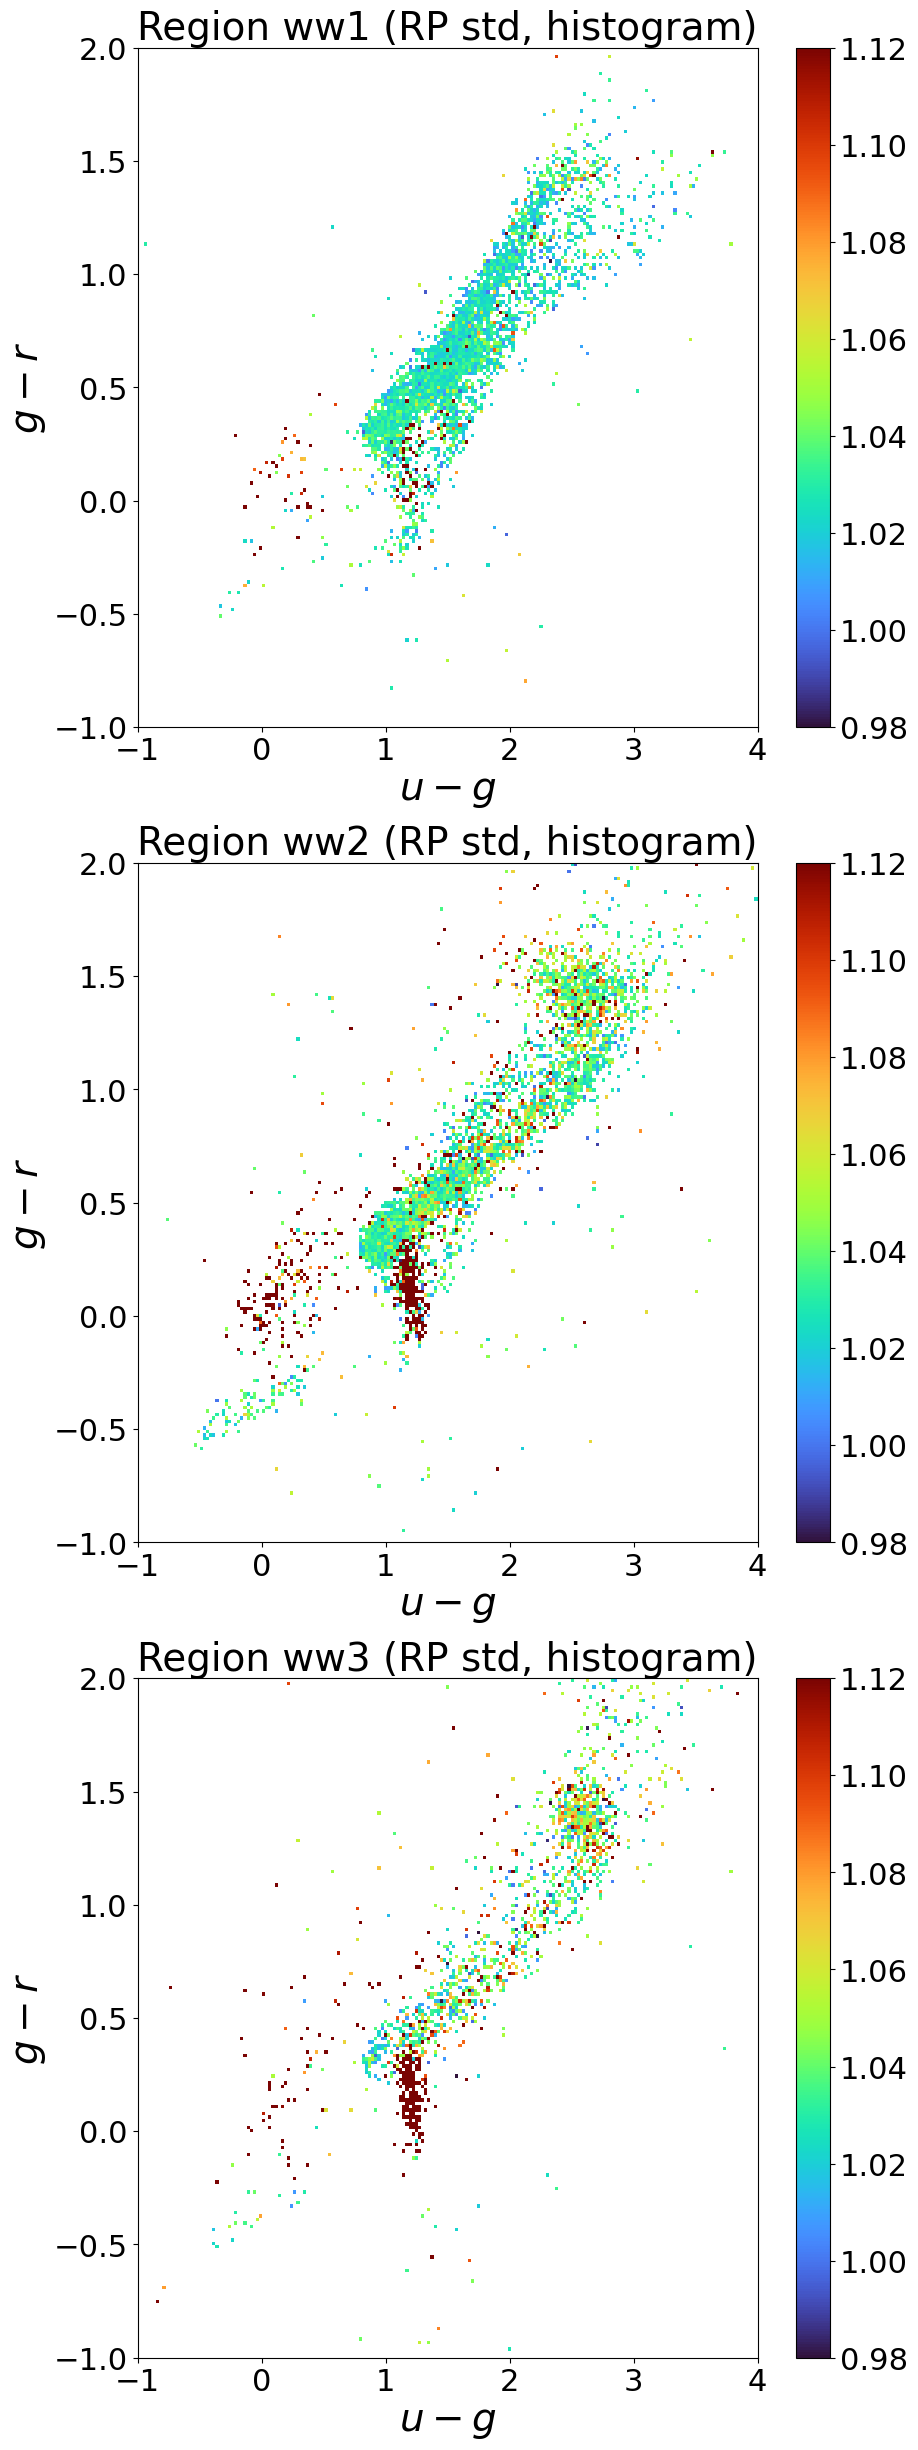

In [26]:
fig, ax = plt.subplots(3, 1, figsize=(10, 30))

S_cc = 1
W_MIN = 0.98
W_MAX = 1.12


ax[0].set_xlabel('$u-g$')
ax[0].set_ylabel('$g-r$')
ax[0].set_xlim(-1, 4)
ax[0].set_ylim(-1, 2)
ax[0].set_title('Region ww1 (RP std, histogram)')

bins_gMr = np.linspace(-1, 2, RES*2)
bins_uMg = np.linspace(-1, 4, RES*2)
hist_median = np.histogram2d(uMg(df1), gMr(df1), bins=(bins_uMg, bins_gMr), weights=df1[RP_STD_COLNAME])[0]/hist1

sc = ax[0].pcolormesh(bins_uMg, bins_gMr, hist_median.T, cmap='turbo', norm='linear', vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)


#

ax[1].set_xlabel('$u-g$')
ax[1].set_ylabel('$g-r$')
ax[1].set_xlim(-1, 4)
ax[1].set_ylim(-1, 2)
ax[1].set_title('Region ww2 (RP std, histogram)')

hist_median = np.histogram2d(uMg(df2), gMr(df2), bins=(bins_uMg, bins_gMr), weights=df2[RP_STD_COLNAME])[0]/hist2

sc = ax[1].pcolormesh(bins_uMg, bins_gMr, hist_median.T, cmap='turbo', norm='linear', vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)


ax[2].set_xlabel('$u-g$')
ax[2].set_ylabel('$g-r$')
ax[2].set_xlim(-1, 4)
ax[2].set_ylim(-1, 2)
ax[2].set_title('Region ww3 (RP std, histogram)')

hist_median = np.histogram2d(uMg(df3), gMr(df3), bins=(bins_uMg, bins_gMr), weights=df3[RP_STD_COLNAME])[0]/hist3

sc = ax[2].pcolormesh(bins_uMg, bins_gMr, hist_median.T, cmap='turbo', norm='linear', vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)

plt.savefig('../figures/cc_regions_histogram_median_rp_std.png', dpi=600)

plt.show()

## sky

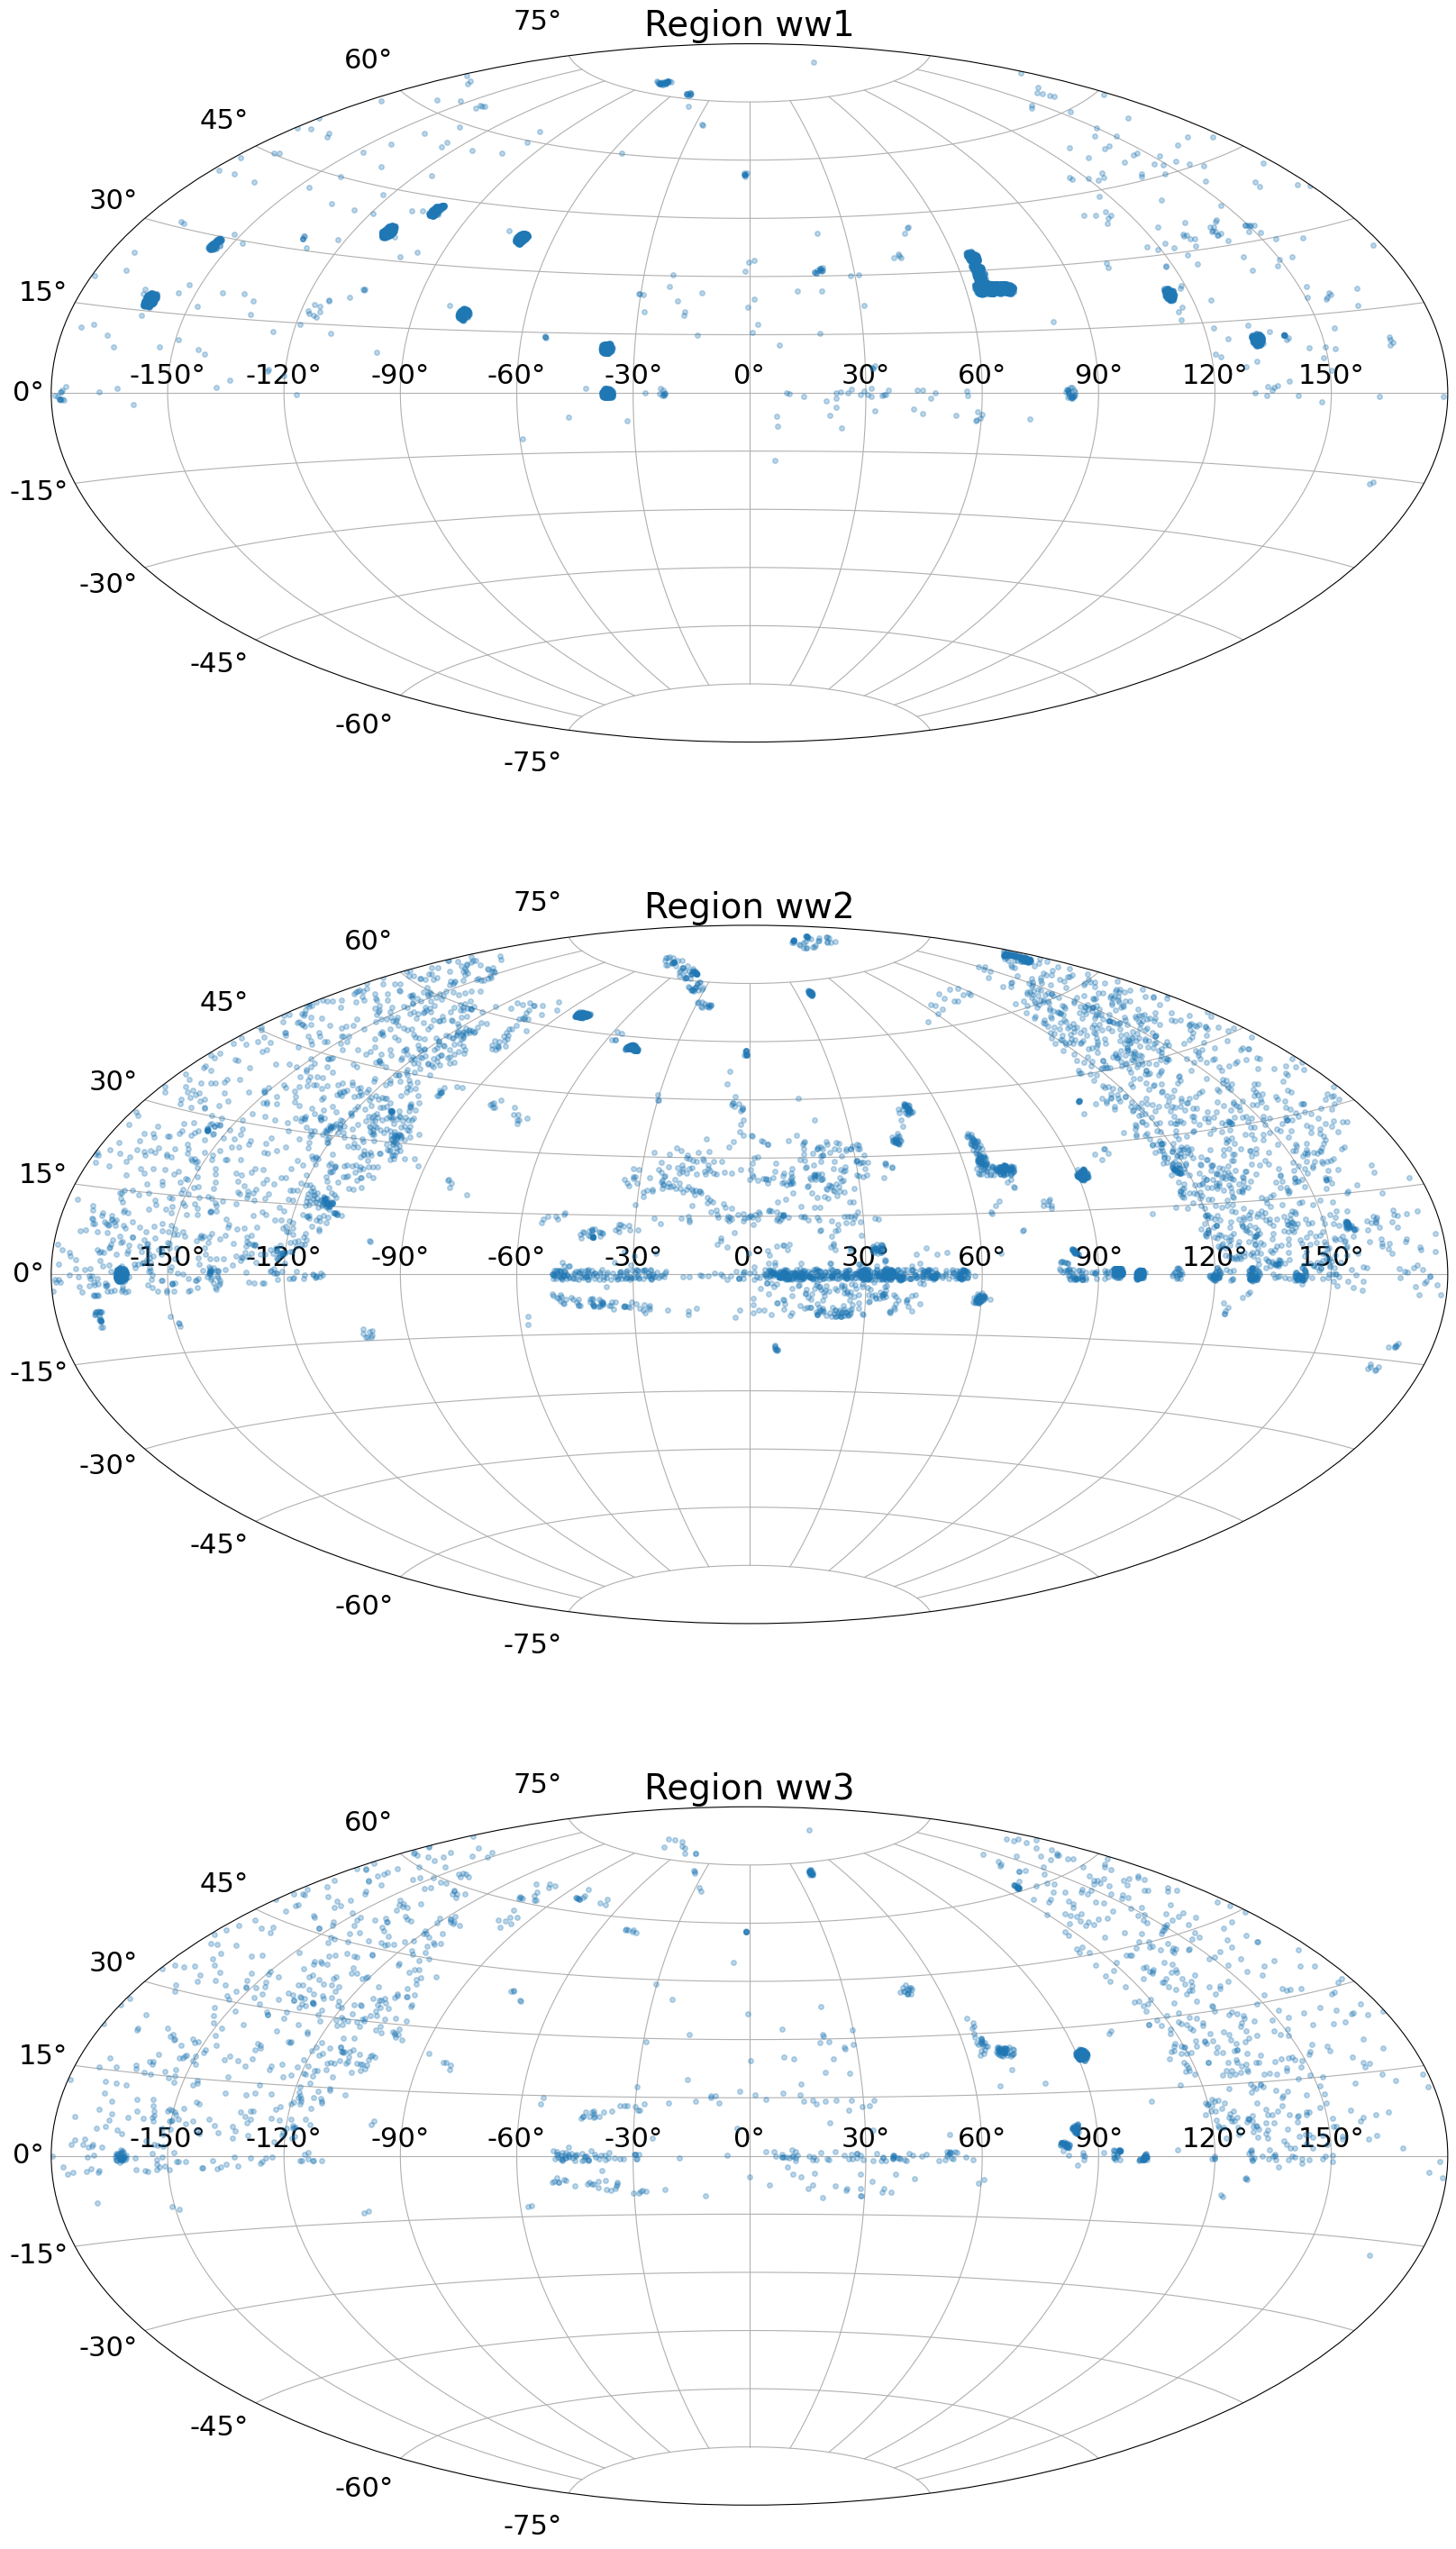

In [27]:
fig = plt.figure(figsize=(20, 36))

def radec(mt):
    ra = mt.gaia_ra * np.pi / 180
    ra[ra > np.pi] -= 2 * np.pi
    dec = mt.gaia_dec * np.pi / 180
    
    return ra, dec

ra1, dec1 = radec(df1)
ra2, dec2 = radec(df2)
ra3, dec3 = radec(df3)

M = 4

ax0 = plt.subplot(311, projection='aitoff')
ax0.plot(ra1, dec1, 'o', markersize=M, alpha=0.3)
ax0.grid(True)
ax0.set_title('Region ww1')

ax1 = plt.subplot(312, projection='aitoff')
ax1.plot(ra2, dec2, 'o', markersize=M, alpha=0.3)
ax1.grid(True)
ax1.set_title('Region ww2')

ax2 = plt.subplot(313, projection='aitoff')
ax2.plot(ra3, dec3, 'o', markersize=M, alpha=0.3)
ax2.grid(True)
ax2.set_title('Region ww3')

plt.savefig('../figures/sky_regions.png', dpi=600)

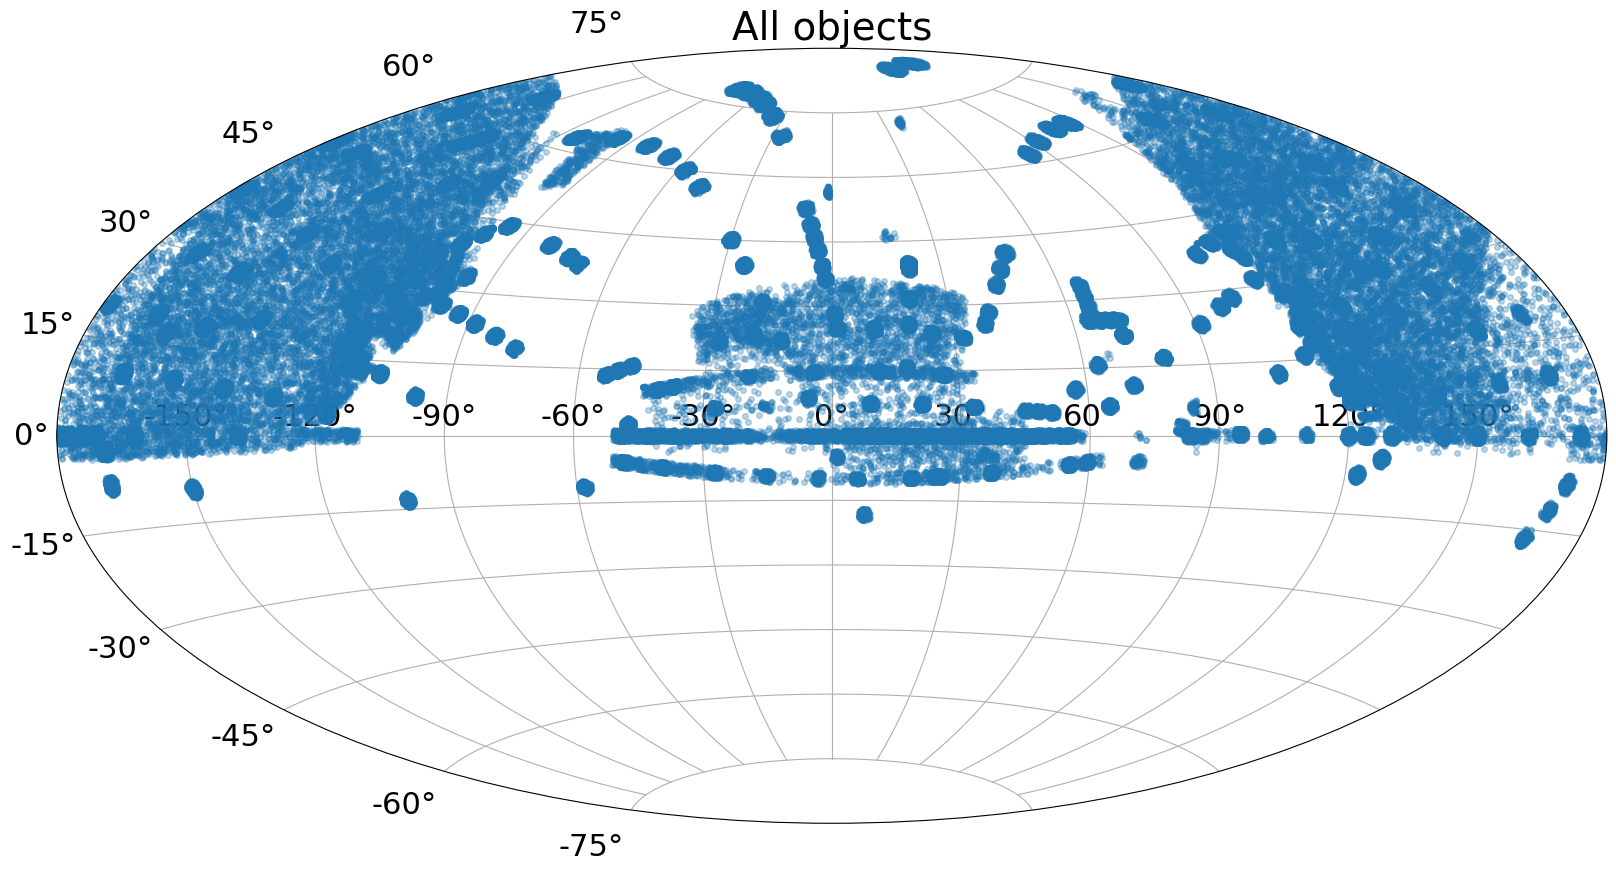

In [28]:
fig = plt.figure(figsize=(20, 12))

ra, dec = radec(DF)

ax = plt.subplot(111, projection='aitoff')
ax.plot(ra, dec, 'o', markersize=M, alpha=0.3)
ax.grid(True)
ax.set_title('All objects')

plt.savefig('../figures/sky_all_objects.png', dpi=600)

In [53]:
# Carroll & Ostlie p. 900

RA_NGP  = 192.8595 * np.pi/180
DEC_NGP = 27.12825 * np.pi/180

def gal_lat(_ra, _dec):    
    b = np.arcsin(np.sin(DEC_NGP)*np.sin(_dec) + np.cos(DEC_NGP)*np.cos(_dec)*np.cos(_ra - RA_NGP))
    return b * 180 / np.pi

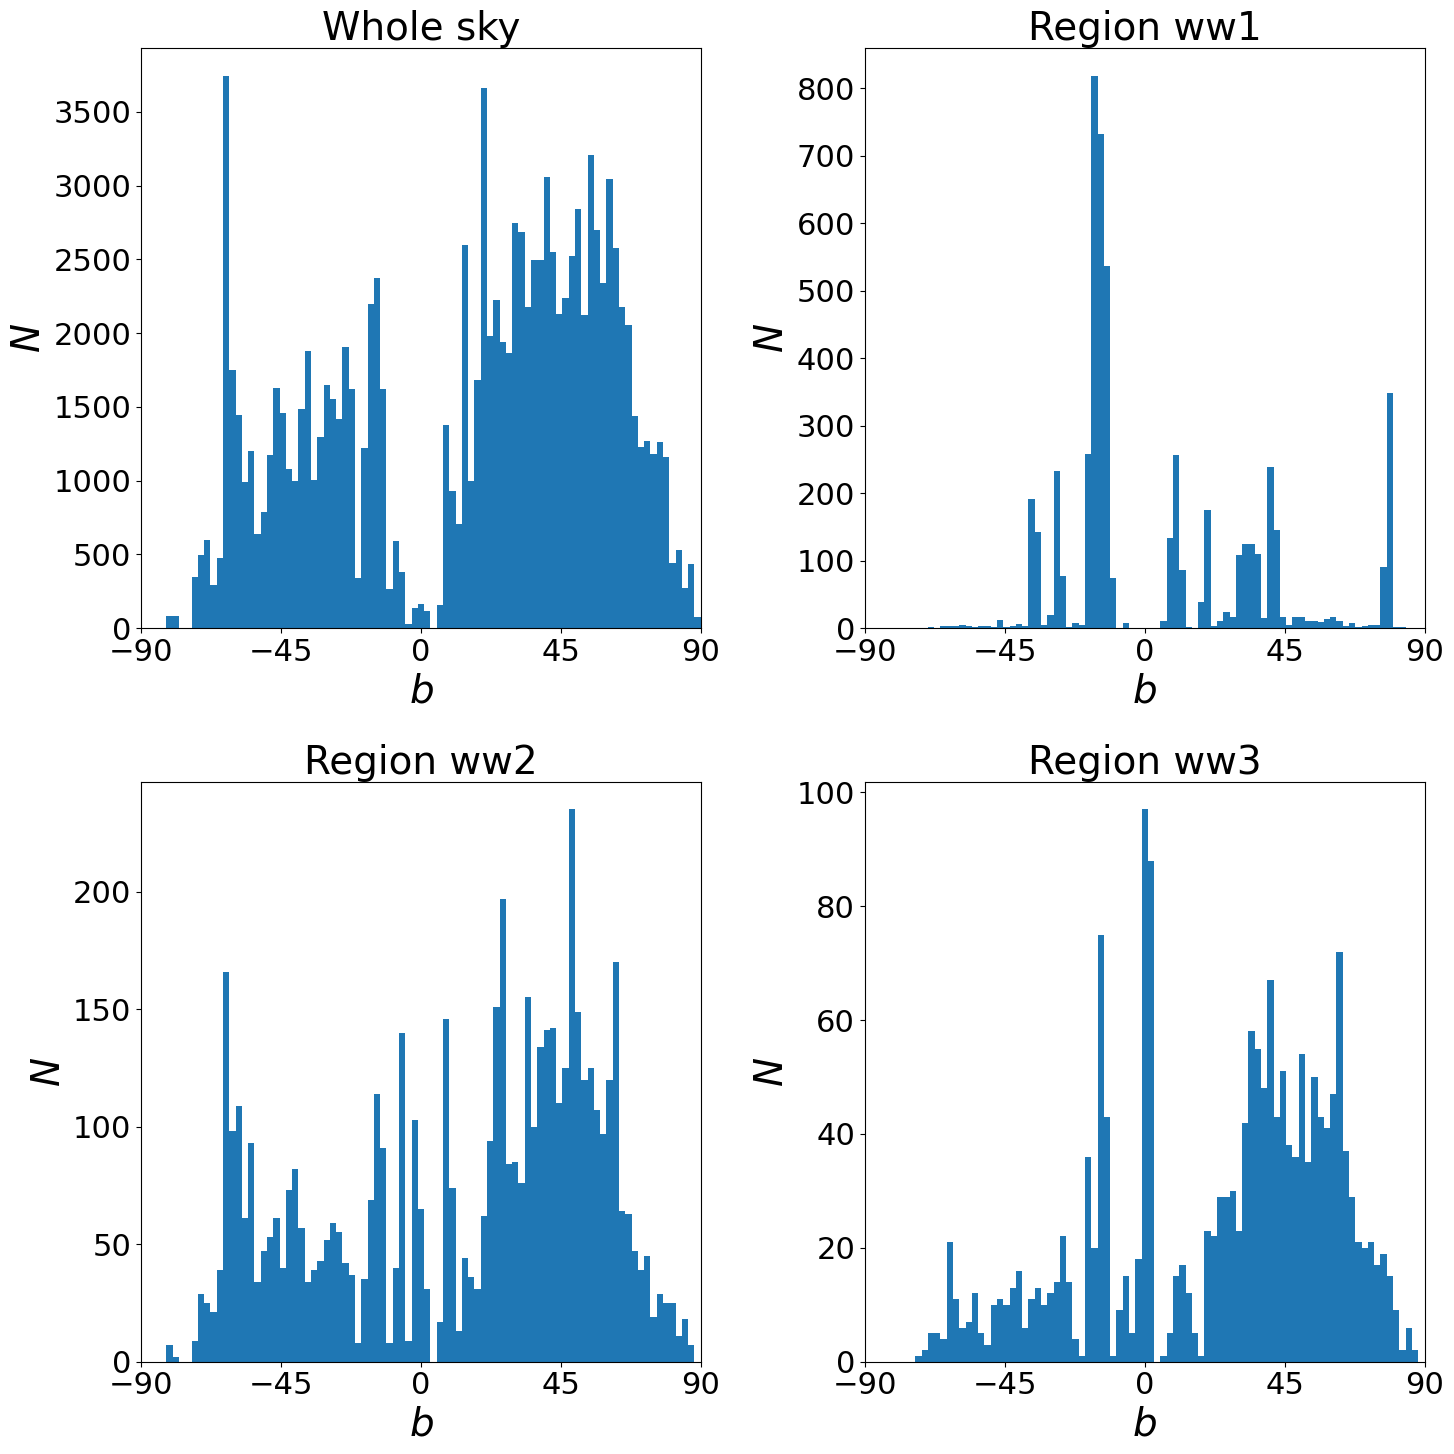

In [57]:
fig, ax = plt.subplots(2, 2, figsize=(15, 15))

bl, bm = -90, 90
bticks = [-bm, -bm//2, 0, bm//2, bm]

S_cc = 1
W_MIN = 0.98
W_MAX = 1.12
bins = np.linspace(bl, bm, 90)

ax[0][0].set_xlabel('$b$')
ax[0][0].set_ylabel('$N$')
ax[0][0].set_xlim(bl, bm)
ax[0][0].set_title('Whole sky')
ax[0][0].hist(gal_lat(ra, dec), bins=bins)
ax[0][0].set_xticks(bticks)
#
ax[0][1].set_xlabel('$b$')
ax[0][1].set_ylabel('$N$')
ax[0][1].set_xlim(bl, bm)
ax[0][1].set_title('Region ww1')
ax[0][1].hist(gal_lat(ra1, dec1), bins=bins)
ax[0][1].set_xticks(bticks)
#
ax[1][0].set_xlabel('$b$')
ax[1][0].set_ylabel('$N$')
ax[1][0].set_xlim(bl, bm)
ax[1][0].set_title('Region ww2')
ax[1][0].hist(gal_lat(ra2, dec2), bins=bins)
ax[1][0].set_xticks(bticks)
#
ax[1][1].set_xlabel('$b$')
ax[1][1].set_ylabel('$N$')
ax[1][1].set_xlim(bl, bm)
ax[1][1].set_title('Region ww3')
ax[1][1].hist(gal_lat(ra3, dec3), bins=bins)
ax[1][1].set_xticks(bticks)


plt.savefig('../figures/b_hist.png', dpi=600)
plt.tight_layout()
plt.show()

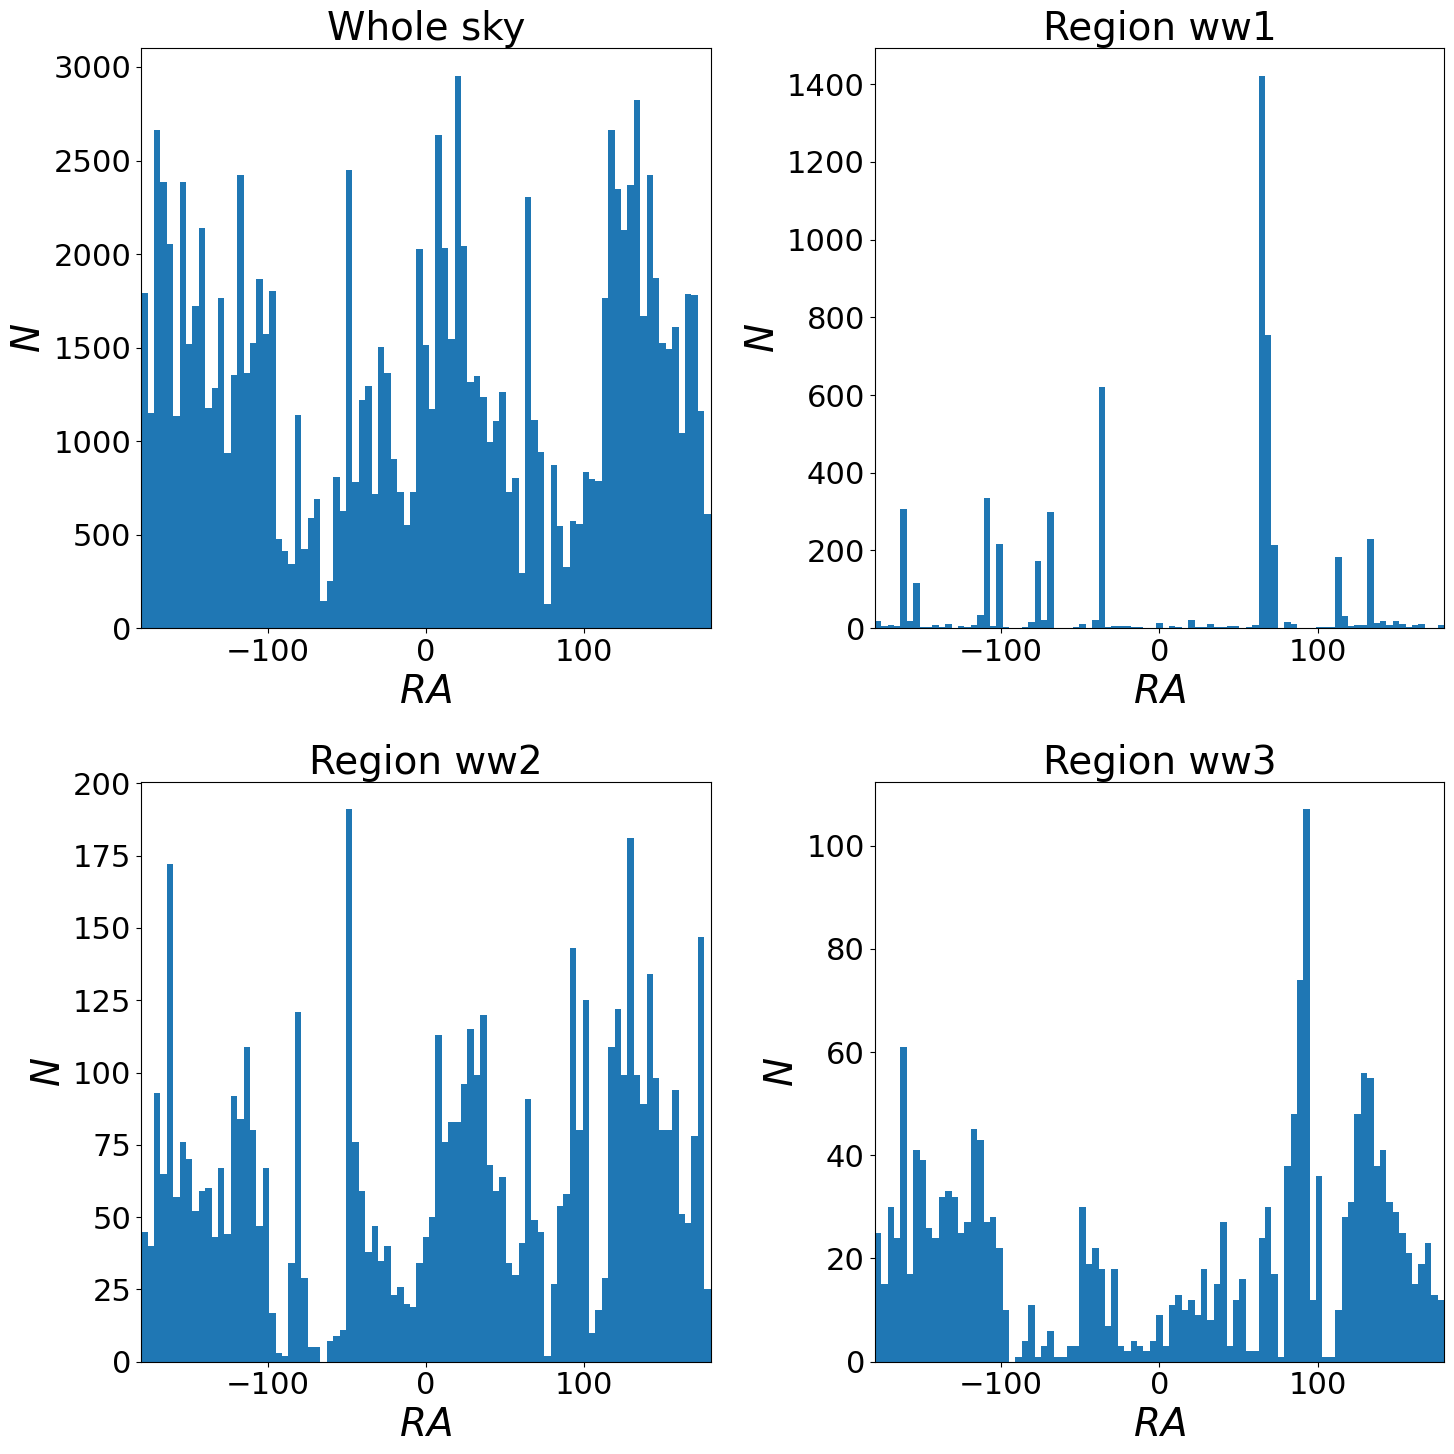

In [60]:
fig, ax = plt.subplots(2, 2, figsize=(15, 15))

S_cc = 1
W_MIN = 0.98
W_MAX = 1.12
bins = np.linspace(-180, 180, 90)

ax[0][0].set_xlabel('$RA$')
ax[0][0].set_ylabel('$N$')
ax[0][0].set_xlim(-180, 180)
ax[0][0].set_title('Whole sky')
ax[0][0].hist((ra)* 180/np.pi, bins=bins)
#
ax[0][1].set_xlabel('$RA$')
ax[0][1].set_ylabel('$N$')
ax[0][1].set_xlim(-180, 180)
ax[0][1].set_title('Region ww1')
ax[0][1].hist((ra1) * 180/np.pi, bins=bins)
#
ax[1][0].set_xlabel('$RA$')
ax[1][0].set_ylabel('$N$')
ax[1][0].set_xlim(-180, 180)
ax[1][0].set_title('Region ww2')
ax[1][0].hist((ra2) * 180/np.pi, bins=bins)
#
ax[1][1].set_xlabel('$RA$')
ax[1][1].set_ylabel('$N$')
ax[1][1].set_xlim(-180, 180)
ax[1][1].set_title('Region ww3')
ax[1][1].hist((ra3) * 180/np.pi, bins=bins)


plt.savefig('../figures/ra_hist.png', dpi=600)
plt.tight_layout()
plt.show()

---
# S82
---

## rms cuts

In [28]:
L = [ 0, 0.02, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45 ]

df_mode1 = DF_S82[DF_S82[W_MEDIAN_COLNAME] > LIM_MODE_MED_UPPER]
cuts = [ df_mode1[(df_mode1[SGW_COLNAME] > L[i]) & (df_mode1[SGW_COLNAME] < L[i+1])] for i in range(len(L)-1)]
L = L[1:]

N_tot    = np.zeros(len(L))
N_nonvar = np.zeros(len(L))
N_var    = np.zeros(len(L))
N_quasar = np.zeros(len(L))
N_unk    = np.zeros(len(L))
N_ambi   = np.zeros(len(L))

# cuts[0].count()
for i in range(len(L)):
    is_nonvar = cuts[i].nonvar_match_num == 1
    is_var    = cuts[i].var_match_num == 1
    is_quasar = cuts[i].quasar_match_num == 1
    
    N_tot[i]    = cuts[i].count().w_median
    N_nonvar[i] = cuts[i][is_nonvar & ~is_var & ~is_quasar].count().w_median
    N_var[i]    = cuts[i][~is_nonvar & is_var & ~is_quasar].count().w_median
    N_quasar[i] = cuts[i][~is_nonvar & ~is_var & is_quasar].count().w_median
    N_unk[i]    = cuts[i][~(is_nonvar | is_var | is_quasar)].count().w_median
    N_ambi[i]   = N_tot[i] - N_nonvar[i] - N_var[i] - N_quasar[i] - N_unk[i]

    
is_nonvar = df_mode1.nonvar_match_num == 1
is_var    = df_mode1.var_match_num == 1
is_quasar = df_mode1.quasar_match_num == 1 
M_var = df_mode1[~is_nonvar & is_var & ~is_quasar].count().w_median

completeness = [ N_var[i]/M_var for i in range(len(L)) ]
purity = [ N_var[i]/N_tot[i] for i in range(len(L)) ]
other_purity = [ N_var[i]/(N_tot[i]-N_unk[i]) for i in range(len(L)) ]

In [29]:
purity

In [30]:
completeness

In [31]:
other_purity

In [32]:
L = np.array(L)
purity = np.array(purity)
other_purity = np.array(other_purity)
completeness = np.array(completeness)

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(20, 16))


ax.set_xlabel('cuts on w_rrms')
ax.set_ylabel('%')
ax.set_title('w rrms cuts - completeness & purity')

ax.bar(np.arange(len(L)) - 0.2, purity*100, width=0.4, label='purity')
ax.bar(np.arange(len(L)) + 0.2, completeness*100, width=0.4, label='completeness')
ax.legend()

ax.set_xticks(range(len(L)), L)

plt.savefig('../figures/completeness_purity.png', dpi=600)

None

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(20, 16))


ax.set_xlabel('cuts on w_rrms')
ax.set_ylabel('%')
ax.set_title('w rrms cuts - completeness & purity')

ax.bar(np.arange(len(L)) - 0.2, other_purity*100, width=0.4, label='other purity')
ax.bar(np.arange(len(L)) + 0.2, completeness*100, width=0.4, label='completeness')
ax.legend()

ax.set_xticks(range(len(L)), L)

plt.savefig('../figures/completeness_other_purity.png', dpi=600)

None

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(20, 16))


ax.set_xlabel('cuts on w_rrms')
ax.set_ylabel('relative count')
ax.set_ylim(0, 1)
ax.set_title('w rrms cuts - shares???')

ax.bar(np.arange(len(L)), N_nonvar/N_tot, width=0.6, label='nonvar')
ax.bar(np.arange(len(L)), N_var/N_tot, width=0.6, label='var', bottom=N_nonvar/N_tot)
ax.bar(np.arange(len(L)), N_quasar/N_tot, width=0.6, label='quasar', bottom=(N_nonvar+N_var)/N_tot)
ax.bar(np.arange(len(L)), N_ambi/N_tot, width=0.6, label='ambiguous', bottom=(N_nonvar+N_var+N_quasar)/N_tot)
ax.bar(np.arange(len(L)), N_unk/N_tot, width=0.6, label='unknown', bottom=(N_nonvar+N_var+N_quasar+N_ambi)/N_tot, color='gray')
ax.legend()

ax.set_xticks(range(len(L)), L)

# plt.savefig('../figures/cut_percentages.png', dpi=600)

None

In [36]:
fig, ax = plt.subplots(6, 2, figsize=(40, 120))

S_cc = 1
W_MAX = 1.2
W_MIN = 0.8

for i in range(6):
    for j in range(2):
        ax[i][j].set_xlabel('$u-g$')
        ax[i][j].set_ylabel('$g-r$')
        ax[i][j].set_xlim(-1, 4)
        ax[i][j].set_ylim(-1, 2)
        ax[i][j].set_title(f'Stripe 82 (w_rrms < {L[2*i+j]})')
       
        sc = ax[i][j].scatter(uMg(cuts[2*i+j]), gMr(cuts[2*i+j]), s=6, label='all', alpha=0.8,
                        cmap='turbo', c='red', vmin=W_MIN, vmax=W_MAX)
        

plt.savefig('../figures/cc_cuts.png', dpi=300)

plt.show()

## var/nonvar/quasar

In [37]:
is_nonvar = DF_S82.nonvar_match_num == 1
is_var    = DF_S82.var_match_num == 1
is_quasar = DF_S82.quasar_match_num == 1

nonvar_subset = DF_S82[is_nonvar & ~is_var & ~is_quasar]
var_subset    = DF_S82[~is_nonvar & is_var & ~is_quasar]
quasar_subset = DF_S82[~is_nonvar & ~is_var & is_quasar]
# ambi_subset   = DF[is_nonvar | is_var | is_quasar & ~(is_nonvar ^ is_var ^ is_quasar)]
none_subset   = DF_S82[~is_nonvar & ~is_var & ~is_quasar]

In [38]:
plt.figure(figsize=(20, 20))

plt.xlim(MIN_SGW, MAX_SGW)
plt.ylim(MIN_W, MAX_W)

plt.xlabel('sG$w$')
plt.ylabel('median $w$')

bins_std_nonvar = np.linspace(0, 0.5, RES*2)
bins_avg_nonvar = np.linspace(0, 2, RES*2)
hist_nonvar, _, _ = np.histogram2d(nonvar_subset[SGW_COLNAME], nonvar_subset[W_MEDIAN_COLNAME],
                                 bins=(bins_std_nonvar, bins_avg_nonvar))
hist_var, _, _    = np.histogram2d(var_subset[SGW_COLNAME], var_subset[W_MEDIAN_COLNAME],
                                 bins=(bins_std, bins_avg))
hist_quasar, _, _ = np.histogram2d(quasar_subset[SGW_COLNAME], quasar_subset[W_MEDIAN_COLNAME],
                                 bins=(bins_std, bins_avg))


plt.pcolormesh(bins_std_nonvar, bins_avg_nonvar, hist_nonvar.T, cmap='Purples', norm=colors.LogNorm(), alpha=1.0)
plt.pcolormesh(bins_std, bins_avg, hist_var.T,    cmap='Blues',   norm=colors.LogNorm(), alpha=0.5)
plt.pcolormesh(bins_std, bins_avg, hist_quasar.T, cmap='Greens',  norm=colors.LogNorm(), alpha=0.5)

# plt.scatter(nonvar_subset[SGW_COLNAME], nonvar_subset[W_MEDIAN_COLNAME], c=C_ORANGE,  s=S, label='nonvar')
# plt.scatter(var_subset[SGW_COLNAME],    var_subset[W_MEDIAN_COLNAME],    c=C_BLUE,    s=S, label='var')
# plt.scatter(quasar_subset[SGW_COLNAME], quasar_subset[W_MEDIAN_COLNAME], c=C_GREEN,   s=S, label='quasar')
# plt.scatter(ambi_subset[SGQ_COLNAME],   ambi_subset[Q_MEDIAN_COLNAME],   c=C_PURPLE,  s=S, label='ambiguous')
# plt.scatter(none_subset[SGQ_COLNAME],   none_subset[Q_MEDIAN_COLNAME],   c=C_BLACK,   s=S, label='unclassified')

plt.legend()
plt.show()

In [39]:
plt.figure(figsize=(20, 20))

plt.xlim(MIN_SGW, MAX_SGW)
plt.ylim(MIN_W, MAX_W)

plt.xlabel('sG$w$')
plt.ylabel('median $w$')

bins_std_nonvar = np.linspace(0, 0.5, RES*2)
bins_avg_nonvar = np.linspace(0, 2, RES*2)
hist_nonvar, _, _ = np.histogram2d(nonvar_subset[SGW_COLNAME], nonvar_subset[W_MEDIAN_COLNAME],
                                 bins=(bins_std_nonvar, bins_avg_nonvar))
hist_var, _, _    = np.histogram2d(var_subset[SGW_COLNAME], var_subset[W_MEDIAN_COLNAME],
                                 bins=(bins_std, bins_avg))
hist_quasar, _, _ = np.histogram2d(quasar_subset[SGW_COLNAME], quasar_subset[W_MEDIAN_COLNAME],
                                 bins=(bins_std, bins_avg))


plt.pcolormesh(bins_std_nonvar, bins_avg_nonvar, hist_nonvar.T, cmap='Oranges', norm=colors.LogNorm(), alpha=1.0)
# plt.pcolormesh(bins_std, bins_avg, hist_var.T,    cmap='Blues',   norm=colors.LogNorm(), alpha=0.5)
# plt.pcolormesh(bins_std, bins_avg, hist_quasar.T, cmap='Greens',  norm=colors.LogNorm(), alpha=0.5)

# plt.scatter(nonvar_subset[SGW_COLNAME], nonvar_subset[W_MEDIAN_COLNAME], c=C_ORANGE,  s=S, label='nonvar')
# plt.scatter(var_subset[SGW_COLNAME],    var_subset[W_MEDIAN_COLNAME],    c=C_BLUE,    s=S, label='var')
# plt.scatter(quasar_subset[SGW_COLNAME], quasar_subset[W_MEDIAN_COLNAME], c=C_GREEN,   s=S, label='quasar')
# plt.scatter(ambi_subset[SGQ_COLNAME],   ambi_subset[Q_MEDIAN_COLNAME],   c=C_PURPLE,  s=S, label='ambiguous')
# plt.scatter(none_subset[SGQ_COLNAME],   none_subset[Q_MEDIAN_COLNAME],   c=C_BLACK,   s=S, label='unclassified')

plt.legend()
plt.show()

In [40]:
plt.figure(figsize=(20, 20))

plt.xlim(MIN_SGW, MAX_SGW)
plt.ylim(MIN_W, MAX_W)

plt.xlabel('$w_{rrms}$')
plt.ylabel('median $w$')

plt.scatter(nonvar_subset[SGW_COLNAME], nonvar_subset[W_MEDIAN_COLNAME], c=CN, s=S, label='nonvar', alpha=AN)
plt.scatter(var_subset[SGW_COLNAME],    var_subset[W_MEDIAN_COLNAME],    c=CV,   s=S, label='var',    alpha=AV)
plt.scatter(quasar_subset[SGW_COLNAME], quasar_subset[W_MEDIAN_COLNAME], c=CQ,  s=S, label='quasar', alpha=AV)
# plt.scatter(ambi_subset[SGQ_COLNAME],   ambi_subset[Q_MEDIAN_COLNAME],   c=C_PURPLE,  s=S, label='ambiguous')
# plt.scatter(none_subset[SGQ_COLNAME],   none_subset[Q_MEDIAN_COLNAME],   c=C_BLACK,   s=S, label='unclassified')

plt.legend()
plt.show()

In [41]:
plt.figure(figsize=(20, 20))

plt.xlim(MIN_SGW, MAX_SGW)
plt.ylim(MIN_W, MAX_W)

plt.xlabel('$w_{rrms}$')
plt.ylabel('$<w>$')

plt.scatter(nonvar_subset[SGW_COLNAME], nonvar_subset[W_MEAN_COLNAME], c=CN,  s=S, label='nonvar', alpha=AN)
plt.scatter(var_subset[SGW_COLNAME],    var_subset[W_MEAN_COLNAME],    c=CV,    s=S, label='var',    alpha=AV)
plt.scatter(quasar_subset[SGW_COLNAME], quasar_subset[W_MEAN_COLNAME], c=CQ,   s=S, label='quasar', alpha=AV)

plt.legend()
plt.show()

In [42]:
plt.figure(figsize=(20, 20))

plt.xlim(MIN_SGW, MAX_SGW)
plt.ylim(MIN_W, MAX_W)

plt.xlabel('$\\sigma_w$')
plt.ylabel('$<w>$')

plt.scatter(nonvar_subset[W_STD_COLNAME], nonvar_subset[W_MEAN_COLNAME], c=CN,  s=S, label='nonvar', alpha=AN)
plt.scatter(var_subset[W_STD_COLNAME],    var_subset[W_MEAN_COLNAME],    c=CV,    s=S, label='var',    alpha=AV)
plt.scatter(quasar_subset[W_STD_COLNAME], quasar_subset[W_MEAN_COLNAME], c=CQ,   s=S, label='quasar', alpha=AV)

plt.legend()
plt.show()

In [43]:
plt.figure(figsize=(20, 20))

plt.xlim(MIN_W, MAX_W)
plt.ylim(MIN_W, MAX_W)

plt.xlabel('median $w$')
plt.ylabel('$<w>$')

plt.scatter(nonvar_subset[W_MEDIAN_COLNAME], nonvar_subset[W_MEAN_COLNAME], c=CN,  s=S, label='nonvar', alpha=AN)
plt.scatter(var_subset[W_MEDIAN_COLNAME],    var_subset[W_MEAN_COLNAME],    c=CV,    s=S, label='var',    alpha=AV)
plt.scatter(quasar_subset[W_MEDIAN_COLNAME], quasar_subset[W_MEAN_COLNAME], c=CQ,   s=S, label='quasar', alpha=AV)

plt.legend()
plt.show()

In [44]:
plt.figure(figsize=(20, 20))

plt.xlim(MIN_SGW, MAX_SGW)
plt.ylim(MIN_SGW, MAX_SGW)

plt.xlabel('$w_{rrms}$')
plt.ylabel('$\\sigma_w$')

plt.scatter(nonvar_subset[SGW_COLNAME], nonvar_subset[W_STD_COLNAME], c=CN,  s=S, label='nonvar', alpha=AN)
plt.scatter(var_subset[SGW_COLNAME],    var_subset[W_STD_COLNAME],    c=CV,    s=S, label='var',    alpha=AV)
plt.scatter(quasar_subset[SGW_COLNAME], quasar_subset[W_STD_COLNAME], c=CQ,   s=S, label='quasar', alpha=AV)

plt.legend()
plt.show()

In [45]:
plt.figure(figsize=(20, 20))

plt.ylim(MIN_SGW, MAX_SGW)

plt.xlabel('mag ($r$)')
plt.ylabel('$w_{rrms}$')

plt.scatter(nonvar_subset[R_MAG_COLNAME], nonvar_subset[SGW_COLNAME], c=CN,  s=S, label='nonvar', alpha=AN)
plt.scatter(var_subset[R_MAG_COLNAME],    var_subset[SGW_COLNAME],    c=CV,    s=S, label='var',    alpha=AV)
plt.scatter(quasar_subset[R_MAG_COLNAME], quasar_subset[SGW_COLNAME], c=CQ,   s=S, label='quasar', alpha=AV)

plt.legend()
plt.show()

In [46]:
plt.figure(figsize=(20, 20))

plt.ylim(MIN_W, MAX_W)

plt.xlabel('SDSS r-band magnitude')
plt.ylabel('median $w$')

plt.scatter(nonvar_subset[R_MAG_COLNAME], nonvar_subset[W_MEDIAN_COLNAME], c=CN,  s=S, label='nonvar', alpha=AN)
plt.scatter(var_subset[R_MAG_COLNAME],    var_subset[W_MEDIAN_COLNAME],    c=CV,  s=S, label='var',    alpha=AV)
plt.scatter(quasar_subset[R_MAG_COLNAME], quasar_subset[W_MEDIAN_COLNAME], c=CQ,   s=S, label='quasar', alpha=AQ)

plt.legend()
plt.show()

In [47]:
plt.figure(figsize=(20, 20))

plt.ylim(MIN_W, MAX_W)

plt.xlabel('Gaia G-band magnitude')
plt.ylabel('median $w$')

plt.scatter(nonvar_subset[GAIA_G_COLNAME], nonvar_subset[W_MEDIAN_COLNAME], c=CN,  s=S, label='nonvar', alpha=AN)
plt.scatter(var_subset[GAIA_G_COLNAME],    var_subset[W_MEDIAN_COLNAME],    c=CV,  s=S, label='var',    alpha=AV)
plt.scatter(quasar_subset[GAIA_G_COLNAME], quasar_subset[W_MEDIAN_COLNAME], c=CQ,   s=S, label='quasar', alpha=AQ)

plt.legend()
plt.show()

In [48]:
plt.figure(figsize=(20, 20))

plt.ylim(MIN_W, MAX_W)

plt.xlabel('$G-r$')
plt.ylabel('median $w$')

mag_diff = lambda x: x[GAIA_G_COLNAME] - x[R_MAG_COLNAME]

plt.scatter(mag_diff(nonvar_subset), nonvar_subset[W_MEDIAN_COLNAME], c=CN,  s=S, label='nonvar', alpha=AN)
plt.scatter(mag_diff(var_subset),    var_subset[W_MEDIAN_COLNAME],    c=CV,  s=S, label='var',    alpha=AV)
plt.scatter(mag_diff(quasar_subset), quasar_subset[W_MEDIAN_COLNAME], c=CQ,   s=S, label='quasar', alpha=AQ)

plt.legend()
plt.show()

In [49]:
from astroquery.gaia import Gaia

query = 'SELECT gs.source_id, gs.phot_bp_rp_excess_factor FROM gaiadr3.gaia_source gs \
         WHERE (gs.ra < 60 OR gs.ra > 300) AND (gs.dec > -1.67 AND gs.dec < 1.67) \
         AND gs.source_id IN ({})'.format(str(list(DF.source_id))[1:-1])

excess_df = Gaia.launch_job_async(query).get_results().to_pandas()

In [ ]:
excess_df

In [ ]:
plt.figure(figsize=(20, 20))

plt.ylim(MIN_W, MAX_W)
plt.xlim(1, 2.5)

plt.xlabel('$\\frac{BP+RP}{G}$')
plt.ylabel('median $w$')

n_ex = pd.merge(nonvar_subset, excess_df, on='source_id')
v_ex = pd.merge(var_subset,    excess_df, on='source_id')
q_ex = pd.merge(quasar_subset, excess_df, on='source_id')

plt.scatter(n_ex['phot_bp_rp_excess_factor'], n_ex[W_MEDIAN_COLNAME], c=CN,  s=S, label='nonvar', alpha=AN)
plt.scatter(v_ex['phot_bp_rp_excess_factor'], v_ex[W_MEDIAN_COLNAME], c=CV,  s=S, label='var',    alpha=AV)
plt.scatter(q_ex['phot_bp_rp_excess_factor'], q_ex[W_MEDIAN_COLNAME], c=CQ,  s=S, label='quasar', alpha=AQ)

plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(20, 20))

plt.ylim(-1, 3)

plt.xlabel('mag ($r$)')
plt.ylabel('$-2.5 \\log(w)$')

m = lambda x: -2.5 * np.log10(x)

plt.scatter(nonvar_subset[R_MAG_COLNAME], m(nonvar_subset[W_MEDIAN_COLNAME]), c=CN,  s=S, label='nonvar', alpha=AN)
plt.scatter(var_subset[R_MAG_COLNAME],    m(var_subset[W_MEDIAN_COLNAME]),    c=CV,    s=S, label='var',    alpha=AV)
plt.scatter(quasar_subset[R_MAG_COLNAME], m(quasar_subset[W_MEDIAN_COLNAME]), c=CQ,   s=S, label='quasar', alpha=AV)

plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(20, 20))

plt.ylim(MIN_W, MAX_W)

plt.xlabel('$g-r$')
plt.ylabel('median $w$')

gMr = lambda x: x[G_MAG_COLNAME] - x[R_MAG_COLNAME]

plt.scatter(gMr(nonvar_subset), nonvar_subset[W_MEDIAN_COLNAME], c=CN,  s=S, label='nonvar', alpha=AN)
plt.scatter(gMr(var_subset),    var_subset[W_MEDIAN_COLNAME],    c=CV,    s=S, label='var',    alpha=AV)
plt.scatter(gMr(quasar_subset), quasar_subset[W_MEDIAN_COLNAME], c=CQ,   s=S, label='quasar', alpha=AV)

plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(20, 20))

plt.ylim(MIN_W, MAX_W)

plt.xlabel('$u-g$')
plt.ylabel('median $\\Delta$')

uMg = lambda x: x[U_MAG_COLNAME] - x[G_MAG_COLNAME]

plt.scatter(uMg(nonvar_subset), nonvar_subset[W_MEDIAN_COLNAME], c=CN,  s=S, label='nonvar', alpha=AN)
plt.scatter(uMg(var_subset),    var_subset[W_MEDIAN_COLNAME],    c=CV,    s=S, label='var',    alpha=AV)
plt.scatter(uMg(quasar_subset), quasar_subset[W_MEDIAN_COLNAME], c=CQ,   s=S, label='quasar', alpha=AV)

plt.legend()
plt.show()

# \Delta

In [ ]:
plt.figure(figsize=(20, 20))

plt.ylim(-0.02, 0.98)

plt.xlabel('mag ($r$)')
plt.ylabel('median $\\Delta$')

plt.scatter(nonvar_subset[R_MAG_COLNAME], nonvar_subset[D_MEDIAN_COLNAME], c=CN,  s=S, label='nonvar', alpha=AN)
plt.scatter(var_subset[R_MAG_COLNAME],    var_subset[D_MEDIAN_COLNAME],    c=CV,    s=S, label='var',    alpha=AV)
plt.scatter(quasar_subset[R_MAG_COLNAME], quasar_subset[D_MEDIAN_COLNAME], c=CQ,   s=S, label='quasar', alpha=AV)

plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(20, 20))

plt.ylim(-0.02, 5.98)

plt.xlabel('mag ($r$)')
plt.ylabel('$-2.5 \\log(\\Delta$)')

plt.scatter(nonvar_subset[R_MAG_COLNAME], m(nonvar_subset[D_MEDIAN_COLNAME]), c=CN,  s=S, label='nonvar', alpha=AN)
plt.scatter(var_subset[R_MAG_COLNAME],    m(var_subset[D_MEDIAN_COLNAME]),    c=CV,    s=S, label='var',    alpha=AV)
plt.scatter(quasar_subset[R_MAG_COLNAME], m(quasar_subset[D_MEDIAN_COLNAME]), c=CQ,   s=S, label='quasar', alpha=AV)

plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(20, 20))

plt.ylim(-0.02, 0.98)

plt.xlabel('$g-r$')
plt.ylabel('median $\\Delta$')

gMr = lambda x: x[G_MAG_COLNAME] - x[R_MAG_COLNAME]

plt.scatter(gMr(nonvar_subset), nonvar_subset[D_MEDIAN_COLNAME], c=CN,  s=S, label='nonvar', alpha=AN)
plt.scatter(gMr(var_subset),    var_subset[D_MEDIAN_COLNAME],    c=CV,    s=S, label='var',    alpha=AV)
plt.scatter(gMr(quasar_subset), quasar_subset[D_MEDIAN_COLNAME], c=CQ,   s=S, label='quasar', alpha=AV)

plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(20, 20))

plt.ylim(-0.02, 5.98)

plt.xlabel('g-r')
plt.ylabel('$-2.5 \\log(\\Delta$)')

plt.scatter(gMr(nonvar_subset), m(nonvar_subset[D_MEDIAN_COLNAME]), c=CN,  s=S, label='nonvar', alpha=AN)
plt.scatter(gMr(var_subset),    m(var_subset[D_MEDIAN_COLNAME]),    c=CV,    s=S, label='var',    alpha=AV)
plt.scatter(gMr(quasar_subset), m(quasar_subset[D_MEDIAN_COLNAME]), c=CQ,   s=S, label='quasar', alpha=AV)

plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(20, 20))

plt.ylim(-0.02, 0.98)

plt.xlabel('$u-g$')
plt.ylabel('median $\\Delta$')

uMg = lambda x: x[U_MAG_COLNAME] - x[G_MAG_COLNAME]

plt.scatter(uMg(nonvar_subset), nonvar_subset[D_MEDIAN_COLNAME], c=CN,  s=S, label='nonvar', alpha=AN)
plt.scatter(uMg(var_subset),    var_subset[D_MEDIAN_COLNAME],    c=CV,    s=S, label='var',    alpha=AV)
plt.scatter(uMg(quasar_subset), quasar_subset[D_MEDIAN_COLNAME], c=CQ,   s=S, label='quasar', alpha=AV)

plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(20, 20))

plt.ylim(-0.02, 5.98)

plt.xlabel('$u-g$')
plt.ylabel('$-2.5 \\log(\\Delta$)')

plt.scatter(uMg(nonvar_subset), m(nonvar_subset[D_MEDIAN_COLNAME]), c=CN,  s=S, label='nonvar', alpha=AN)
plt.scatter(uMg(var_subset),    m(var_subset[D_MEDIAN_COLNAME]),    c=CV,    s=S, label='var',    alpha=AV)
plt.scatter(uMg(quasar_subset), m(quasar_subset[D_MEDIAN_COLNAME]), c=CQ,   s=S, label='quasar', alpha=AV)

plt.legend()
plt.show()

## color-color

In [ ]:
TITLES = [['all', 'nonvar'], ['var', 'quasar']]

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(20, 20))

S_cc = 4
W_MAX = 1.2
W_MIN = 0.8

for i in (0, 1):
    for j in (0, 1):
        ax[i][j].set_xlabel('$u-g$')
        ax[i][j].set_ylabel('$g-r$')
        ax[i][j].set_xlim(-1, 4)
        ax[i][j].set_ylim(-1, 2)
        ax[i][j].set_title(TITLES[i][j])

unambi_subset = pd.concat([nonvar_subset, var_subset, quasar_subset])

sc = ax[0][0].scatter(uMg(unambi_subset), gMr(unambi_subset), s=S_cc, label='all',
                      cmap='turbo', c=unambi_subset[W_MEDIAN_COLNAME], vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)

sc = ax[0][1].scatter(uMg(nonvar_subset), gMr(nonvar_subset), s=S_cc, label='all',
                      cmap='turbo', c=nonvar_subset[W_MEDIAN_COLNAME], vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)

sc = ax[1][0].scatter(uMg(var_subset), gMr(var_subset), s=S_cc, label='all',
                      cmap='turbo', c=var_subset[W_MEDIAN_COLNAME], vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)

sc = ax[1][1].scatter(uMg(quasar_subset), gMr(quasar_subset), s=S_cc, label='all',
                      cmap='turbo', c=quasar_subset[W_MEDIAN_COLNAME], vmin=W_MIN, vmax=W_MAX)
plt.colorbar(sc)

# plt.scatter(uMg(nonvar_subset), gMr(nonvar_subset), c=C_ORANGE,  s=S, label='nonvar', alpha=AN)
# plt.scatter(uMg(var_subset),    gMr(var_subset),    c=C_BLUE,    s=S, label='var',    alpha=AV)
# plt.scatter(uMg(quasar_subset), gMr(quasar_subset), c=C_GREEN,   s=S, label='quasar', alpha=AV)

plt.show()

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(20, 20))

for i in (0, 1):
    for j in (0, 1):
        ax[i][j].set_xlabel('$u-g$')
        ax[i][j].set_ylabel('$g-r$')
        ax[i][j].set_xlim(-1, 4)
        ax[i][j].set_ylim(-1, 2)
        ax[i][j].set_title(TITLES[i][j])

unambi_subset = pd.concat([nonvar_subset, var_subset, quasar_subset])

D_MAX = 0.2
CMAP = 'turbo'

sc = ax[0][0].scatter(uMg(unambi_subset), gMr(unambi_subset), s=S_cc, label='all', alpha=1,
                      cmap=CMAP, c=(unambi_subset[D_MEDIAN_COLNAME]), vmin=0, vmax=D_MAX)
plt.colorbar(sc)

sc = ax[0][1].scatter(uMg(nonvar_subset), gMr(nonvar_subset), s=S_cc, label='all', alpha=1,
                      cmap=CMAP, c=(nonvar_subset[D_MEDIAN_COLNAME]), vmin=0, vmax=D_MAX)
plt.colorbar(sc)

sc = ax[1][0].scatter(uMg(var_subset), gMr(var_subset), s=S_cc, label='all', alpha=1,
                      cmap=CMAP, c=(var_subset[D_MEDIAN_COLNAME]), vmin=0, vmax=D_MAX)
plt.colorbar(sc)

sc = ax[1][1].scatter(uMg(quasar_subset), gMr(quasar_subset), s=S_cc, label='all', alpha=1,
                      cmap=CMAP, c=(quasar_subset[D_MEDIAN_COLNAME]), vmin=0, vmax=D_MAX)
plt.colorbar(sc)

plt.show()

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(20, 20))

MIN_uMg = -1
MAX_uMg = 4
MIN_gMr = -1
MAX_gMr = 2
N_BINS = 80

bins_uMg = np.linspace(MIN_uMg, MAX_uMg, N_BINS)
bins_gMr = np.linspace(MIN_gMr, MAX_gMr, N_BINS)

# all
counts, _, _ = np.histogram2d(uMg(unambi_subset), gMr(unambi_subset), bins=(bins_uMg, bins_gMr))
sums,   _, _ = np.histogram2d(uMg(unambi_subset), gMr(unambi_subset), bins=(bins_uMg, bins_gMr),
                              weights=(unambi_subset[D_MEDIAN_COLNAME]))
with np.errstate(divide='ignore', invalid='ignore'):
    mD = masked_invalid(sums/counts).T

mesh = ax[0][0].pcolormesh(bins_uMg, bins_gMr, mD, cmap=CMAP,
                           vmin=0, vmax=D_MAX)
fig.colorbar(mesh)

# nonvar
counts, _, _ = np.histogram2d(uMg(nonvar_subset), gMr(nonvar_subset), bins=(bins_uMg, bins_gMr))
sums,   _, _ = np.histogram2d(uMg(nonvar_subset), gMr(nonvar_subset), bins=(bins_uMg, bins_gMr),
                              weights=(nonvar_subset[D_MEDIAN_COLNAME]))
with np.errstate(divide='ignore', invalid='ignore'):
    mD = masked_invalid(sums/counts).T

mesh = ax[0][1].pcolormesh(bins_uMg, bins_gMr, mD, cmap=CMAP,
                           vmin=0, vmax=D_MAX)
fig.colorbar(mesh)

# var
counts, _, _ = np.histogram2d(uMg(var_subset), gMr(var_subset), bins=(bins_uMg, bins_gMr))
sums,   _, _ = np.histogram2d(uMg(var_subset), gMr(var_subset), bins=(bins_uMg, bins_gMr),
                              weights=(var_subset[D_MEDIAN_COLNAME]))
with np.errstate(divide='ignore', invalid='ignore'):
    mD = masked_invalid(sums/counts).T

mesh = ax[1][0].pcolormesh(bins_uMg, bins_gMr, mD, cmap=CMAP,
                           vmin=0, vmax=D_MAX)
fig.colorbar(mesh)

# quasar
counts, _, _ = np.histogram2d(uMg(quasar_subset), gMr(quasar_subset), bins=(bins_uMg, bins_gMr))
sums,   _, _ = np.histogram2d(uMg(quasar_subset), gMr(quasar_subset), bins=(bins_uMg, bins_gMr),
                              weights=(quasar_subset[D_MEDIAN_COLNAME]))
with np.errstate(divide='ignore', invalid='ignore'):
    mD = masked_invalid(sums/counts).T

mesh = ax[1][1].pcolormesh(bins_uMg, bins_gMr, mD, cmap=CMAP,
                           vmin=0, vmax=D_MAX)
fig.colorbar(mesh)
    

for i in (0, 1):
    for j in (0, 1):
        ax[i][j].set_xlabel('$u-g$')
        ax[i][j].set_ylabel('$g-r$')
        ax[i][j].set_xlim(-1, 4)
        ax[i][j].set_ylim(-1, 2)
        ax[i][j].set_title(TITLES[i][j])

# plt.scatter(uMg(nonvar_subset), gMr(nonvar_subset), c=C_ORANGE,  s=S, label='nonvar', alpha=AN)
# plt.scatter(uMg(var_subset),    gMr(var_subset),    c=C_BLUE,    s=S, label='var',    alpha=AV)
# plt.scatter(uMg(quasar_subset), gMr(quasar_subset), c=C_GREEN,   s=S, label='quasar', alpha=AV)

plt.show()

# second mode

In [ ]:
w_075_subset = nonvar_subset[(nonvar_subset[W_MEDIAN_COLNAME] < 0.77) & (nonvar_subset[W_MEDIAN_COLNAME] > 0.72) & (nonvar_subset[SGW_COLNAME] < 0.04)]
for objId in w_075_subset['objId']:
    print(objId)

In [ ]:
w_075_subset = nonvar_subset[(nonvar_subset[W_MEDIAN_COLNAME] < 0.77) & (nonvar_subset[W_MEDIAN_COLNAME] > 0.72) & (nonvar_subset[SGW_COLNAME] < 0.04)]
for objId in w_075_subset['source_id']:
    print(objId)

In [ ]:
w_075_subset

In [ ]:
plt.figure(figsize=(20, 20))

plt.xlim(-1, 4)
plt.ylim(-1, 2)

plt.xlabel('$u-g$')
plt.ylabel('$g-r$')

plt.scatter(uMg(w_075_subset), gMr(w_075_subset), s=S)

In [ ]:
plt.figure(figsize=(20, 20))

plt.scatter(w_075_subset['gaia_dec'], w_075_subset['gaia_ra'], s=S)

In [ ]:
list(w_075_subset['source_id'])

In [ ]:
from astroquery.gaia import Gaia

query = 'SELECT gs.source_id, gs.parallax, gs.pmra, gs.pmdec FROM gaiadr3.gaia_source gs \
         WHERE (gs.ra < 60 OR gs.ra > 300) AND (gs.dec > -1.67 AND gs.dec < 1.67) \
         AND gs.source_id IN ({})'.format(str(list(w_075_subset.source_id))[1:-1])

pdat = Gaia.launch_job_async(query).get_results().to_pandas()

In [ ]:
pdat

In [ ]:
w_075_subset = pd.merge(w_075_subset, pdat, left_on='source_id', right_on='source_id')

In [ ]:
mag_abs = w_075_subset[R_MAG_COLNAME] + 5 + 5*np.log10(w_075_subset['parallax'])

plt.figure(figsize=(20, 20))

plt.xlim(-1, 4)
plt.gca().invert_yaxis()

plt.xlabel('$g-r$')
plt.ylabel('$M_r$')

plt.scatter(gMr(w_075_subset), mag_abs, s=S)